# EDA — Score d'accès aux services publics

## Contexte
Cet indicateur mesure la **proximité et la disponibilité des services publics** pour les habitants d'Île-de-France (et plus particulièrement Paris). Il agrège sept jeux de données couvrant :

| # | Jeu de données | Service public couvert |
|---|----------------|------------------------|
| 1 | Points d'accueil police — Paris | Sécurité / accueil |
| 2 | Établissements hospitaliers franciliens | Santé |
| 3 | Bureaux de poste & agences postales IDF | Services postaux |
| 4 | Établissements scolaires — écoles élémentaires | Éducation primaire |
| 5 | Postes publics des bibliothèques | Culture / numérique |
| 6 | Secteurs scolaires — collèges | Éducation secondaire |
| 7 | Secteurs scolaires — maternelles | Petite enfance |

**Objectif :** Explorer chaque dataset, évaluer sa qualité, identifier les variables géographiques et construire les briques d'un score composite d'accessibilité aux services publics.

In [4]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({
    'figure.dpi': 110,
    'figure.figsize': (12, 5),
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})

DATA_DIR = Path('sources')
print(f'Dossier source : {DATA_DIR.resolve()}')
print(f'Fichiers disponibles :')
for f in sorted(DATA_DIR.iterdir()):
    print(f'  {f.name}  ({f.stat().st_size / 1024:.1f} Ko)')

Dossier source : C:\Users\tearl\Downloads\lebonplan\sources
Fichiers disponibles :
  carte-des-points-daccueil-police-a-paris.csv  (16.7 Ko)
  etablissements-scolaires-ecoles-elementaires.parquet  (45.1 Ko)
  les_bureaux_de_poste_et_agences_postales_en_idf.parquet  (166.0 Ko)
  les_etablissements_hospitaliers_franciliens.csv  (519.4 Ko)
  postes-publics-des-bibliotheques.parquet  (5.2 Ko)
  secteurs-scolaires-colleges.parquet  (20620.0 Ko)
  secteurs-scolaires-maternelles.parquet  (27536.5 Ko)


---
## 1. Chargement des 7 datasets

In [5]:
# Dataset 1 – Points d’accueil de la police à Paris
df_police = pd.read_csv(
    DATA_DIR / 'carte-des-points-daccueil-police-a-paris.csv',
    sep=';',
    encoding='utf-8'
)

# Dataset 2 – Établissements hospitaliers franciliens
df_hopitaux = pd.read_csv(
    DATA_DIR / 'les_etablissements_hospitaliers_franciliens.csv',
    sep=';',
    encoding='utf-8',
    low_memory=False
)

# Dataset 3 – Bureaux de poste & agences postales IDF
df_poste = pd.read_parquet(DATA_DIR / 'les_bureaux_de_poste_et_agences_postales_en_idf.parquet')

# Dataset 4 – Écoles élémentaires
df_ecoles_elem = pd.read_parquet(DATA_DIR / 'etablissements-scolaires-ecoles-elementaires.parquet')

# Dataset 5 – Postes publics des bibliothèques
df_biblio = pd.read_parquet(DATA_DIR / 'postes-publics-des-bibliotheques.parquet')

# Dataset 6 – Secteurs scolaires – Collèges
df_colleges = pd.read_parquet(DATA_DIR / 'secteurs-scolaires-colleges.parquet')

# Dataset 7 – Secteurs scolaires – Maternelles
df_maternelles = pd.read_parquet(DATA_DIR / 'secteurs-scolaires-maternelles.parquet')

datasets = {
    'Police (Paris)': df_police,
    'Hôpitaux (IDF)': df_hopitaux,
    'Bureaux de poste (IDF)': df_poste,
    'Écoles élémentaires': df_ecoles_elem,
    'Bibliothèques': df_biblio,
    'Secteurs collèges': df_colleges,
    'Secteurs maternelles': df_maternelles,
}

print(' Tous les datasets chargés avec succès.')

 Tous les datasets chargés avec succès.


---
## 2. Vue d'ensemble synthétique

In [6]:
rows = []
for name, df in datasets.items():
    nb_missing = df.isnull().sum().sum()
    pct_missing = nb_missing / (df.shape[0] * df.shape[1]) * 100
    nb_dupl = df.duplicated().sum()
    rows.append({
        'Dataset': name,
        'Lignes': df.shape[0],
        'Colonnes': df.shape[1],
        'Valeurs manquantes': nb_missing,
        '% manquant': round(pct_missing, 2),
        'Doublons': nb_dupl,
    })

overview = pd.DataFrame(rows).set_index('Dataset')
display(overview.style
        .background_gradient(subset=['% manquant'], cmap='Reds')
        .background_gradient(subset=['Doublons'], cmap='Oranges')
        .format({'% manquant': '{:.2f}%'}))

ImportError: Missing optional dependency 'Jinja2'. DataFrame.style requires jinja2. Use pip or conda to install Jinja2.

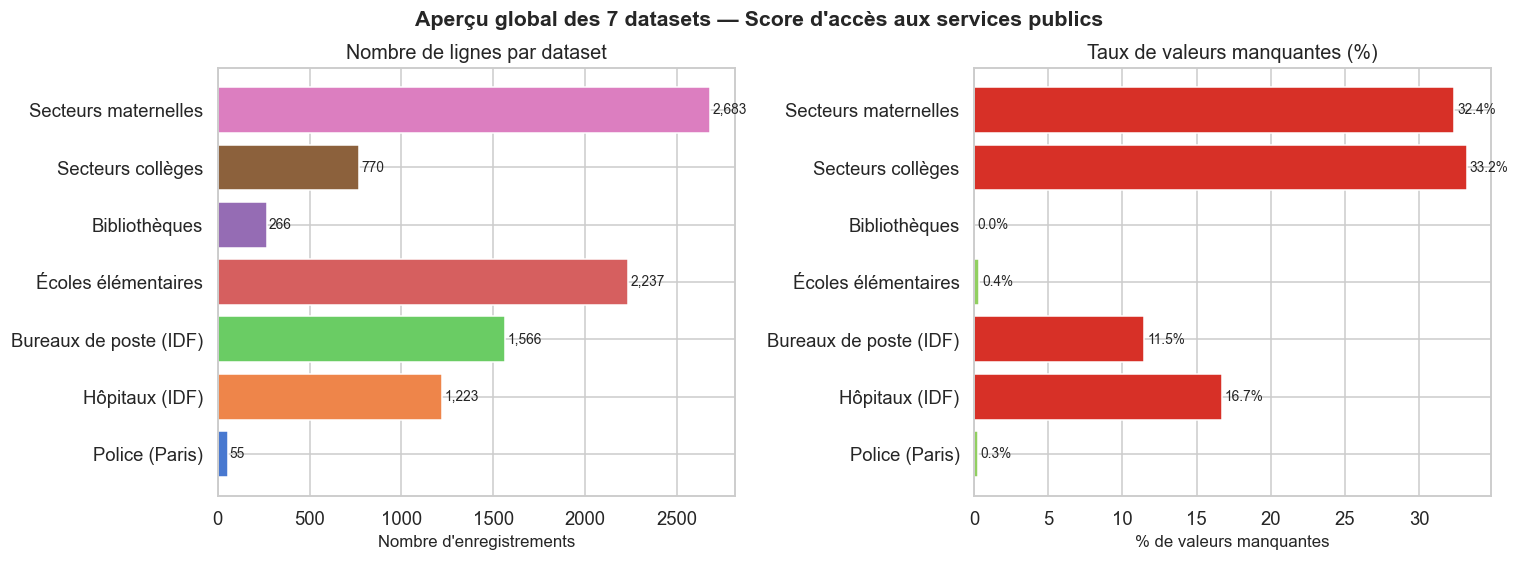

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

names = list(datasets.keys())
lignes = [df.shape[0] for df in datasets.values()]
pct_missing_vals = [df.isnull().sum().sum() / (df.shape[0]*df.shape[1])*100 for df in datasets.values()]

bars = axes[0].barh(names, lignes, color=sns.color_palette('muted', len(names)))
axes[0].set_title('Nombre de lignes par dataset')
axes[0].set_xlabel('Nombre d\'enregistrements')
for bar, v in zip(bars, lignes):
    axes[0].text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2, f'{v:,}', va='center', fontsize=9)

colors_miss = ['#d73027' if p > 10 else '#fc8d59' if p > 5 else '#91cf60' for p in pct_missing_vals]
bars2 = axes[1].barh(names, pct_missing_vals, color=colors_miss)
axes[1].set_title('Taux de valeurs manquantes (%)')
axes[1].set_xlabel('% de valeurs manquantes')
for bar, v in zip(bars2, pct_missing_vals):
    axes[1].text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2, f'{v:.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.suptitle('Aperçu global des 7 datasets — Score d\'accès aux services publics', y=1.02, fontsize=14, fontweight='bold')
plt.show()

---
## 3. Dataset 1 — Points d'accueil police (Paris)

**Service public couvert :** Sécurité et accueil des citoyens  
**Périmètre géographique :** Paris intra-muros (arrondissements)

In [ ]:
print('=== INFORMATIONS GÉNÉRALES ===')
print(f'Dimensions : {df_police.shape[0]} lignes × {df_police.shape[1]} colonnes')
print('\nColonnes et types :')
print(df_police.dtypes)
print('\n--- Aperçu ---')
display(df_police.head())

=== INFORMATIONS GÉNÉRALES ===
Dimensions : 55 lignes × 7 colonnes

Colonnes et types :
ardt             str
service          str
adresse          str
téléphone        str
horaires         str
accessibilité    str
WGS84            str
dtype: object

--- Aperçu ---


,ardt,service,adresse,téléphone,horaires,accessibilité,WGS84
0,12e,DPGP Gare de Lyon,"80, allée de Bercy Voie N",01 53 02 94 00,tous les jours de 6 h30 à 22h40,Ce point d'accueil dispose d'aménagements spéc...,"48.840578, 2.381345"
1,7e,Commissariat central,"9, rue Fabert",01 44 18 69 07,7j/7 24h/24,Ce point d'accueil dispose d'aménagements spéc...,"48.8618757, 2.3116095"
2,16e,Commissariat central,62 avenue Mozart,01 55 74 50 00,7j/7 24h/24,Ce point d'accueil dispose d'aménagements spéc...,"48.8541871, 2.2690746"
3,19e,BDEP Amérique,"12, rue Augustin Thierry",01 56 41 30 00,du lundi au vendredi 9h - 20h,Ce point d'accueil ne dispose pas encore d'amé...,"48.8762512, 2.39369"
4,3e,Commissariat central,"4 bis, 6 rue aux Ours",01 42 76 13 00,7j/7 24h/24,Ce point d'accueil dispose d'aménagements spéc...,"48.8632377, 2.3516301"


In [9]:
print('VALEURS MANQUANTES')
miss = df_police.isnull().sum()
miss_pct = (miss / len(df_police) * 100).round(2)
miss_df = pd.DataFrame({'Manquants': miss, '% manquant': miss_pct}).query('Manquants > 0')
if miss_df.empty:
    print('Aucune valeur manquante.')
else:
    display(miss_df)

print(f'\nDOUBLONS')
print(f'Lignes dupliquées : {df_police.duplicated().sum()}')

print(f'\nSTATISTIQUES DESCRIPTIVES')
display(df_police.describe(include='all'))

VALEURS MANQUANTES


,Manquants,% manquant
horaires,1,1.82



DOUBLONS
Lignes dupliquées : 0

STATISTIQUES DESCRIPTIVES


,ardt,service,adresse,téléphone,horaires,accessibilité,WGS84
count,55,55,55,55,54,55,55
unique,20,35,53,55,11,2,52
top,12e,Commissariat central,"9, rue Fabert",01 53 02 94 00,7j/7 24h/24,Ce point d'accueil dispose d'aménagements spéc...,"48.8618757, 2.3116095"
freq,5,12,2,1,21,28,2


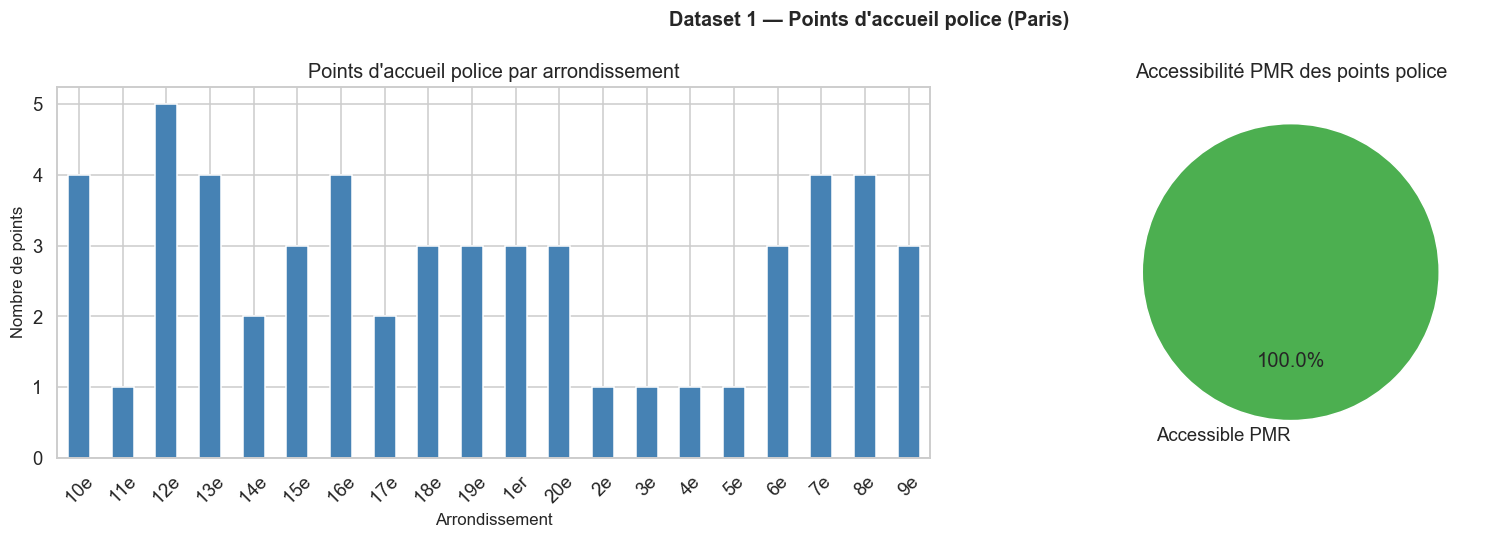


Nombre total de points d'accueil police : 55
Arrondissements couverts : 20
Services distincts : 35


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ardt_counts = df_police['ardt'].value_counts().sort_index()
ardt_counts.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Points d\'accueil police par arrondissement')
axes[0].set_xlabel('Arrondissement')
axes[0].set_ylabel('Nombre de points')
axes[0].tick_params(axis='x', rotation=45)

# Accessibilité PMR
acces_counts = df_police['accessibilité'].str.contains('mobilité réduite', na=False, case=False)
acces_labels = acces_counts.map({True: 'Accessible PMR', False: 'Non renseigné/autre'})
acces_labels.value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%',
                                    colors=['#4CAF50', '#FF9800'], startangle=90)
axes[1].set_title('Accessibilité PMR des points police')
axes[1].set_ylabel('')

plt.suptitle('Dataset 1 — Points d\'accueil police (Paris)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'\nNombre total de points d\'accueil police : {len(df_police)}')
print(f'Arrondissements couverts : {df_police["ardt"].nunique()}')
print(f'Services distincts : {df_police["service"].nunique()}')

In [11]:
df_police[['lat', 'lon']] = (
    df_police['WGS84']
    .str.split(',', expand=True)
    .apply(lambda s: s.str.strip())
    .astype(float)
)
print('Coordonnées géographiques (lat/lon) extraites.')
print(f"  Latitude  : min={df_police['lat'].min():.4f}, max={df_police['lat'].max():.4f}")
print(f"  Longitude : min={df_police['lon'].min():.4f}, max={df_police['lon'].max():.4f}")

import folium
from folium.plugins import MarkerCluster
from IPython.display import HTML

centre_lat = df_police['lat'].mean()
centre_lon = df_police['lon'].mean()

carte_police = folium.Map(location=[centre_lat, centre_lon], zoom_start=13, tiles='CartoDB positron')
cluster = MarkerCluster(name="Points d'accueil police").add_to(carte_police)

for _, row in df_police.iterrows():
    pmr = 'mobilité réduite' in str(row.get('accessibilité', '')).lower()
    couleur = 'green' if pmr else 'blue'
    popup_txt = (
        f"<b>{row['service']}</b><br>"
        f"{row['adresse']}<br>"
        f"Arr. : {row['ardt']}<br>"
        f"{'Accessible PMR' if pmr else '—'}"
    )
    folium.Marker(
        location=[row['lat'], row['lon']],
        popup=folium.Popup(popup_txt, max_width=250),
        tooltip=row['service'],
        icon=folium.Icon(color=couleur, icon='shield', prefix='fa'),
    ).add_to(cluster)

folium.LayerControl().add_to(carte_police)
HTML(carte_police._repr_html_())


Coordonnées géographiques (lat/lon) extraites.
  Latitude  : min=48.8247, max=48.8924
  Longitude : min=2.2638, max=2.4064


ModuleNotFoundError: No module named 'folium'

---
## 4. Dataset 2 — Établissements hospitaliers franciliens

**Service public couvert :** Santé  
**Périmètre géographique :** Île-de-France

In [12]:
print('INFORMATIONS GÉNÉRALES')
print(f'Dimensions : {df_hopitaux.shape[0]} lignes × {df_hopitaux.shape[1]} colonnes')
print('\nColonnes et types :')
print(df_hopitaux.dtypes)
print('\n--- Aperçu ---')
display(df_hopitaux.head())

INFORMATIONS GÉNÉRALES
Dimensions : 1223 lignes × 31 colonnes

Colonnes et types :
finess_et                                   int64
finess_ej                                   int64
raison_sociale                             object
raison_sociale_entite_juridique            object
adresse_administrative_1                   object
adresse_administrative_2                   object
num_voie                                  float64
cpt_num                                    object
type_voie                                  object
voie                                       object
adresse_complete                           object
complement_adresse                         object
num_dept                                    int64
dept                                       object
cp_ville                                   object
num_tel                                    object
num_fax                                    object
num_cat                                     int64
categorie_de_l_et

,finess_et,finess_ej,raison_sociale,raison_sociale_entite_juridique,adresse_administrative_1,adresse_administrative_2,num_voie,cpt_num,type_voie,voie,...,num_siret,code_ape,code_tarif,lib_tarification,code_psph,participant_service_public_hospitalier,date_ouverture,lat,lng,wgs84
0,920002508,920808037,"CTRE LONG SEJOUR ""LES ABONDANCES""",CENTRE DE LONG SEJOUR LES ABONDANCES,NaN,NaN,52.0,NaN,R,DES ABONDANCES,...,2.692010e+13,8610Z,17,Autorité mixte ARS PCG dotation globale,1.0,Etablissement public de santé,1901-01-01,48.846139,2.230283,"48.8461386,2.2302831"
1,920300258,920000809,CLINIQUE DE CHATILLON,CENTRE DE SOINS DE SUITE ET DE RÉADAPTATION CA...,NaN,NaN,17.0,T,R,DES FAUVETTES,...,7.853169e+13,8610Z,7,ARS établissements de santé non financés dotat...,0.0,Non concerné,1968-01-01,48.807142,2.282165,"48.8071422,2.2821651"
2,750802373,750011348,CMP ENFANTS - A.D.H.M.I,CENTRE MEDICO-PSYCHOLOGIQUE ENFANTS DE L'A.D.H...,NaN,75I08,26.0,NaN,BD,BRUNE,...,7.845736e+13,NaN,4,ARS établissements PSPH dotation globale,6.0,Etablissement de santé privé d’intérêt collectif,1904-04-04,48.827010,2.307775,"48.8270097,2.3077751"
3,930700380,930140025,CENTRE MEDICO-PSY,NaN,CMP 93G12,NaN,191.0,NaN,R,SADI CARNOT,...,2.693009e+13,NaN,3,ARS établissements Publics de santé dotation g...,1.0,Etablissement public de santé,1904-04-04,48.875728,2.425086,"48.8757275,2.4250856"
4,940804503,940721400,C.M.P.PSY.INFANTO-JUV.- ST MAUR,CTRE MEDICO-PSYCHOLOGIQUE PSY.INFANTO-JUVENILE...,NaN,NaN,91.0,NaN,BD,RABELAIS,...,7.857059e+13,NaN,15,ARS privé hors PSPH sous dotation globale,7.0,"Etab de santé privé non lucratif, non déclar i...",1976-01-01,48.805441,2.483242,"48.805441,2.4832421"


In [14]:
print('VALEURS MANQUANTES')
miss = df_hopitaux.isnull().sum()
miss_pct = (miss / len(df_hopitaux) * 100).round(2)
miss_df = pd.DataFrame({'Manquants': miss, '% manquant': miss_pct}).query('Manquants > 0').sort_values('% manquant', ascending=False)
if miss_df.empty:
    print('Aucune valeur manquante.')
else:
    display(miss_df)

print(f'\nDOUBLONS (sur finess_et)')
print(f'Doublons sur identifiant finess : {df_hopitaux["finess_et"].duplicated().sum()}')
print(f'Doublons lignes entières : {df_hopitaux.duplicated().sum()}')

print(f'\nSTATISTIQUES DESCRIPTIVES (colonnes numériques)')
display(df_hopitaux.describe())

VALEURS MANQUANTES


,Manquants,% manquant
cpt_num,1166,95.34
complement_adresse,1157,94.60
adresse_administrative_1,1120,91.58
adresse_administrative_2,1007,82.34
code_ape,582,47.59
raison_sociale_entite_juridique,553,45.22
num_fax,421,34.42
num_siret,136,11.12
num_tel,92,7.52
num_voie,67,5.48



DOUBLONS (sur finess_et)
Doublons sur identifiant finess : 0
Doublons lignes entières : 0

STATISTIQUES DESCRIPTIVES (colonnes numériques)


,finess_et,finess_ej,num_voie,num_dept,num_cat,num_type,num_siret,code_tarif,code_psph,lat,lng
count,1.223000e+03,1.223000e+03,1156.000000,1223.000000,1223.000000,1223.000000,1.087000e+03,1223.000000,1216.000000,1223.000000,1223.000000
mean,8.633225e+08,8.479902e+08,41.491349,86.298446,242.838921,1108.134914,3.684180e+13,5.022077,1.702303,48.835607,2.348229
std,8.213321e+07,1.017153e+08,130.960755,8.213202,112.181950,3.748512,1.852776e+13,5.992658,2.091376,0.132301,0.224751
min,7.500001e+08,3.100212e+08,1.000000,75.000000,101.000000,1101.000000,1.800360e+13,1.000000,0.000000,48.262183,1.600489
25%,7.703003e+08,7.508059e+08,6.000000,77.000000,156.000000,1103.000000,2.691000e+13,3.000000,1.000000,48.792876,2.250823
50%,9.108112e+08,9.100194e+08,17.000000,91.000000,161.000000,1110.000000,2.693012e+13,3.000000,1.000000,48.850071,2.340938
75%,9.307009e+08,9.301400e+08,41.000000,93.000000,355.000000,1111.000000,3.840493e+13,7.000000,1.000000,48.910656,2.447110
max,9.508093e+08,9.508057e+08,3133.000000,95.000000,444.000000,1113.000000,9.722021e+13,99.000000,9.000000,49.154970,3.316633


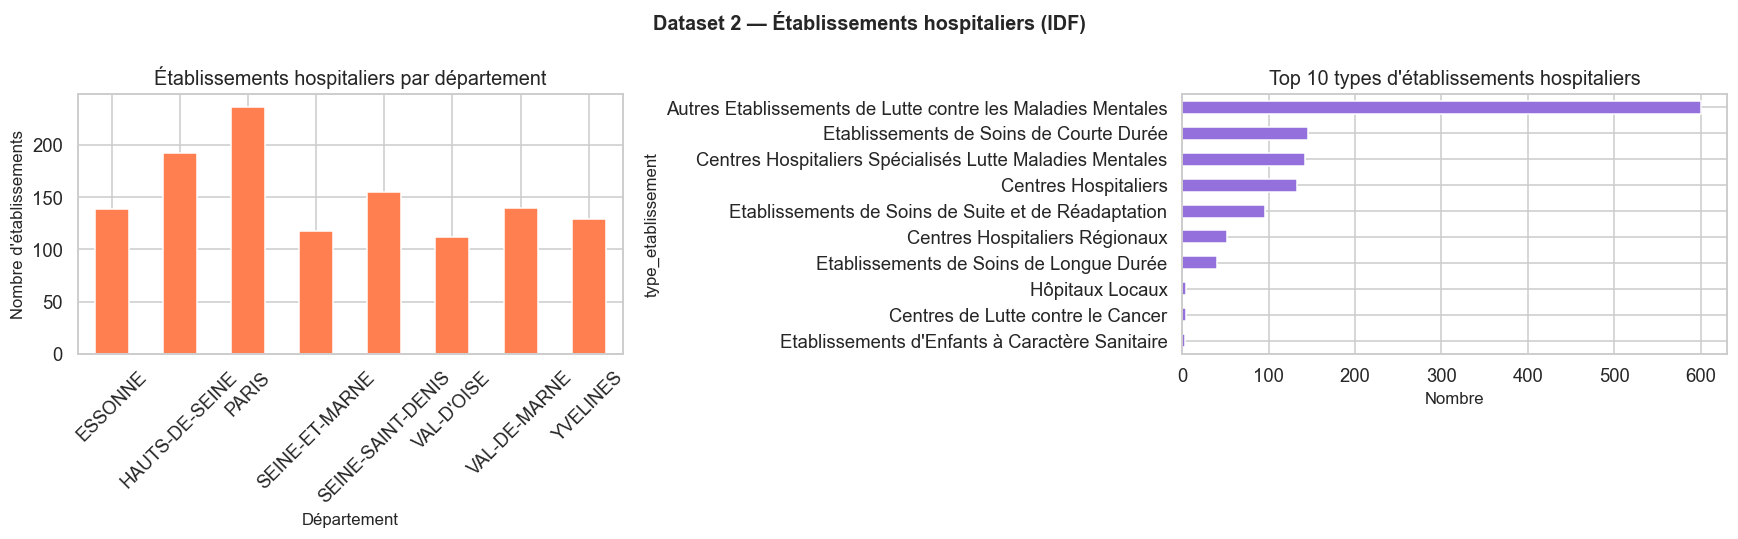

Nombre total d'établissements : 1223
Départements couverts : 8
Types d'établissements : 11


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

dept_counts = df_hopitaux['dept'].value_counts().sort_index()
dept_counts.plot(kind='bar', ax=axes[0], color='coral', edgecolor='white')
axes[0].set_title('Établissements hospitaliers par département')
axes[0].set_xlabel('Département')
axes[0].set_ylabel('Nombre d\'établissements')
axes[0].tick_params(axis='x', rotation=45)

type_counts = df_hopitaux['type_etablissement'].value_counts().head(10)
type_counts.plot(kind='barh', ax=axes[1], color='mediumpurple', edgecolor='white')
axes[1].set_title('Top 10 types d\'établissements hospitaliers')
axes[1].set_xlabel('Nombre')
axes[1].invert_yaxis()

plt.suptitle('Dataset 2 — Établissements hospitaliers (IDF)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Nombre total d\'établissements : {len(df_hopitaux)}')
print(f'Départements couverts : {df_hopitaux["dept"].nunique()}')
print(f'Types d\'établissements : {df_hopitaux["type_etablissement"].nunique()}')

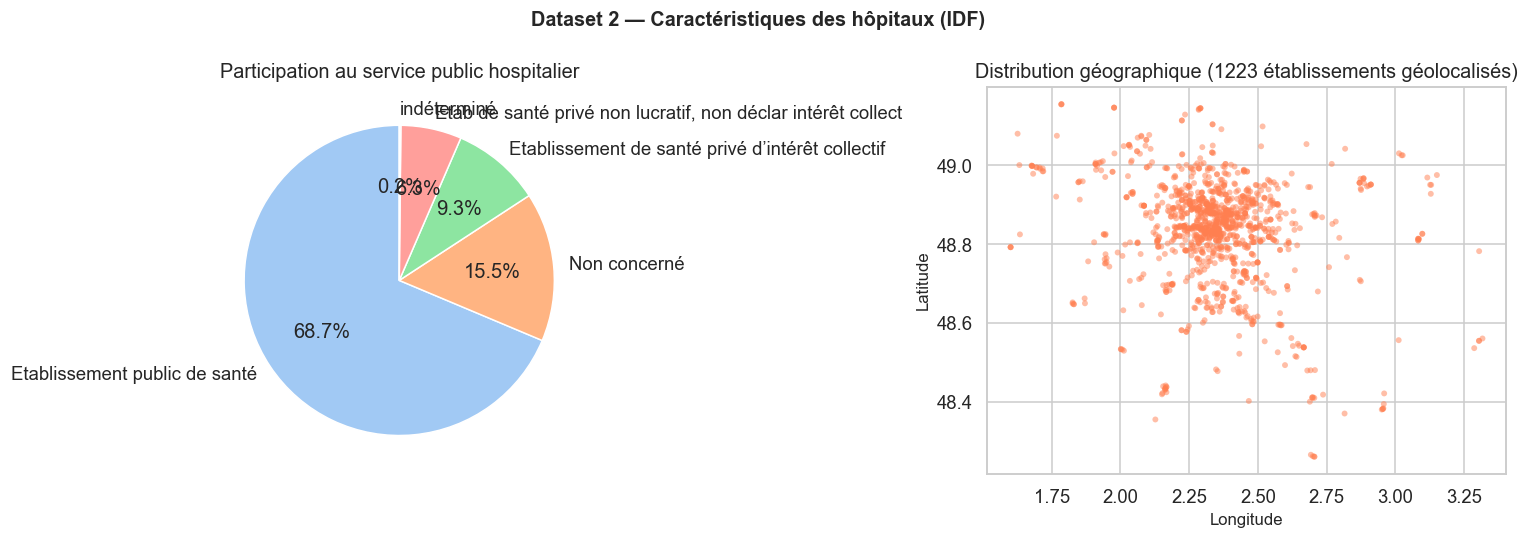

Établissements géolocalisés : 1223 / 1223


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

psph = df_hopitaux['participant_service_public_hospitalier'].value_counts()
psph.plot(kind='pie', ax=axes[0], autopct='%1.1f%%',
          colors=sns.color_palette('pastel'), startangle=90)
axes[0].set_title('Participation au service public hospitalier')
axes[0].set_ylabel('')

df_hop_geo = df_hopitaux.dropna(subset=['lat', 'lng'])
axes[1].scatter(df_hop_geo['lng'], df_hop_geo['lat'],
                c='coral', s=15, alpha=0.5, edgecolors='none')
axes[1].set_title(f'Distribution géographique ({len(df_hop_geo)} établissements géolocalisés)')
axes[1].set_xlabel('Longitude')
axes[1].set_ylabel('Latitude')

plt.suptitle('Dataset 2 — Caractéristiques des hôpitaux (IDF)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Établissements géolocalisés : {len(df_hop_geo)} / {len(df_hopitaux)}')

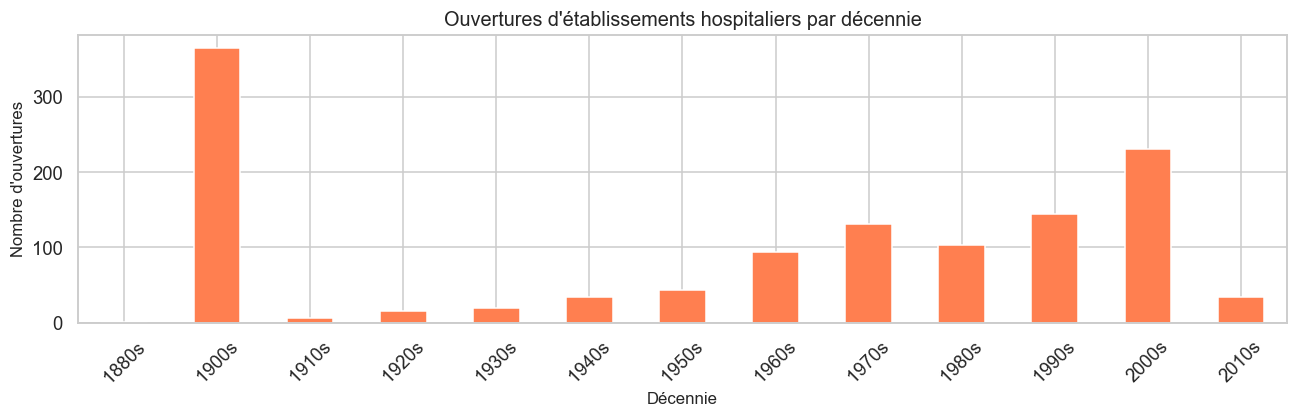

Établissements avec date d'ouverture : 1223 / 1223


In [ ]:
df_hopitaux['date_ouverture'] = pd.to_datetime(df_hopitaux['date_ouverture'], errors='coerce')
df_hop_date = df_hopitaux.dropna(subset=['date_ouverture'])
df_hop_date['decade'] = (df_hop_date['date_ouverture'].dt.year // 10 * 10).astype(str) + 's'

decade_counts = df_hop_date['decade'].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(12, 4))
decade_counts.plot(kind='bar', ax=ax, color='coral', edgecolor='white')
ax.set_title('Ouvertures d\'établissements hospitaliers par décennie')
ax.set_xlabel('Décennie')
ax.set_ylabel('Nombre d\'ouvertures')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

print(f'Établissements avec date d\'ouverture : {len(df_hop_date)} / {len(df_hopitaux)}')

---
## 5. Dataset 3 — Bureaux de poste & agences postales (IDF)

**Service public couvert :** Services postaux  
**Périmètre géographique :** Île-de-France

In [15]:
print('INFORMATIONS GÉNÉRALES')
print(f'Dimensions : {df_poste.shape[0]} lignes × {df_poste.shape[1]} colonnes')
print('\nColonnes et types :')
print(df_poste.dtypes)
print('\nAperçu')
display(df_poste.head())

INFORMATIONS GÉNÉRALES
Dimensions : 1566 lignes × 25 colonnes

Colonnes et types :
libelle_du_site                         object
caracteristique_du_site                 object
adresse                                 object
complement_d_adresse                    object
lieu_dit                                object
code_postal                              int64
localite                                object
pays                                    object
latitude                                object
longitude                               object
precision_du_geocodage                  object
numero_de_telephone                      int64
site_acores_de_rattachement             object
code_insee                               int64
dep                                     object
identifiant_a                           object
reverse_geoloc_commune_nom_com          object
reverse_geoloc_commune_insee_com         int64
reverse_geoloc_epci_nom_epci            object
reverse_geoloc_epci_code

,libelle_du_site,caracteristique_du_site,adresse,complement_d_adresse,lieu_dit,code_postal,localite,pays,latitude,longitude,...,identifiant_a,reverse_geoloc_commune_nom_com,reverse_geoloc_commune_insee_com,reverse_geoloc_epci_nom_epci,reverse_geoloc_epci_code_epci,reverse_geoloc_departement_nom_dep,reverse_geoloc_departement_insee_dep,reverse_geoloc_region_nom_reg,reverse_geoloc_region_insee_reg,geo
0,FRANCONVILLE GUYON APC AP,Agence postale communale,CENTRE COMMERCIAL AVENUE DES MARAIS,AGENCE POSTALE COMMUNALE,EPINE GUYON,95130,FRANCONVILLE LA GARENNE,FRANCE,48.996073998,2.2209386035,...,12826D,Franconville,95252,CA Val Parisis,200058485,Val-d'Oise,95,Île-de-France,11,b'\x01\x01\x00\x00\x00\xbb\xa6cu{\xc4\x01@*\xe...
1,CERGY SME LPR RP,Relais poste,12 PLACE DES TOULEUSES,TABAC LES TOULEUSES CC LES TOULEUSES,None,95000,CERGY,FRANCE,49.030038746,2.0829225668,...,13101D,Cergy,95127,CA de Cergy-Pontoise,249500109,Val-d'Oise,95,Île-de-France,11,b'\x01\x01\x00\x00\x00\x0f\r\x84N\xd3\xa9\x00@...
2,SARCELLES SABLONS AP,Agence postale communale,14 RUE RAOUL DUFY,None,None,95200,SARCELLES,FRANCE,48.9723,2.3808,...,15799D,Sarcelles,95585,CA Roissy Pays de France,200055655,Val-d'Oise,95,Île-de-France,11,b'\x01\x01\x00\x00\x00\xce\x88\xd2\xde\xe0\x0b...
3,PERSAN BEAUMONT SNCF RELAY,Point partenaire,PLACE DE LA GARE,VESTIBULE,None,95340,PERSAN,FRANCE,49.1479,2.2792,...,17167D,Persan,95487,CC du Haut Val d'Oise,249500489,Val-d'Oise,95,Île-de-France,11,b'\x01\x01\x00\x00\x00yX\xa85\xcd;\x02@\t\x8a\...
4,ANDILLY BP,Bureau de Poste,1 PLACE LOUIS JEAN FINOT,None,None,95580,ANDILLY,FRANCE,49.004917,2.299529,...,17411A,Andilly,95014,CA Plaine Vallée,200056380,Val-d'Oise,95,Île-de-France,11,b'\x01\x01\x00\x00\x00\xf1\xa0\xd9uoe\x02@\xe3...


In [ ]:
print('VALEURS MANQUANTES')
miss = df_poste.isnull().sum()
miss_pct = (miss / len(df_poste) * 100).round(2)
miss_df = pd.DataFrame({'Manquants': miss, '% manquant': miss_pct}).query('Manquants > 0').sort_values('% manquant', ascending=False)
if miss_df.empty:
    print('Aucune valeur manquante.')
else:
    display(miss_df)

print(f'\nDOUBLONS')
print(f'Lignes dupliquées : {df_poste.duplicated().sum()}')

print(f'\nSTATISTIQUES DESCRIPTIVES')
display(df_poste.describe(include='all'))

=== VALEURS MANQUANTES ===


,Manquants,% manquant
site_acores_de_rattachement,1566,100.0000
lieu_dit,1541,98.4000
complement_d_adresse,1062,67.8200
precision_du_geocodage,320,20.4300



=== DOUBLONS ===
Lignes dupliquées : 0


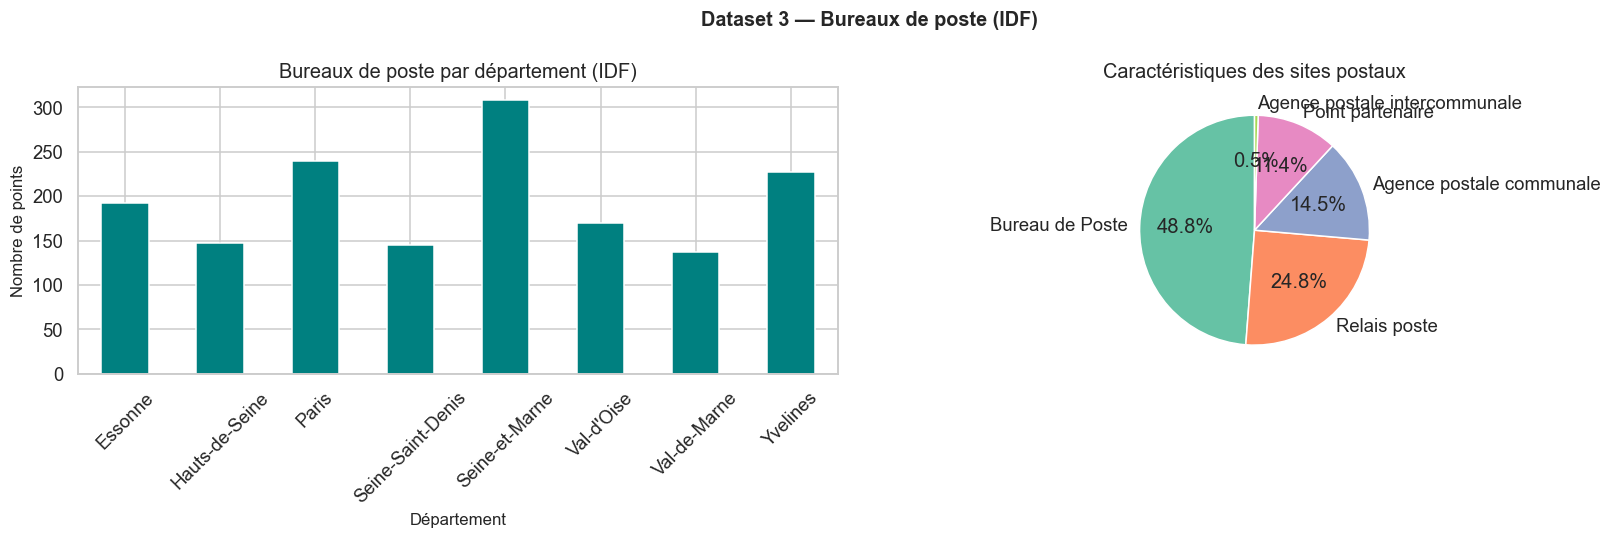

Nombre total de points postaux : 1566
Départements couverts : 8
Types de sites : 5


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

dep_counts = df_poste['reverse_geoloc_departement_nom_dep'].value_counts().sort_index()
dep_counts.plot(kind='bar', ax=axes[0], color='teal', edgecolor='white')
axes[0].set_title('Bureaux de poste par département (IDF)')
axes[0].set_xlabel('Département')
axes[0].set_ylabel('Nombre de points')
axes[0].tick_params(axis='x', rotation=45)

caract = df_poste['caracteristique_du_site'].value_counts()
caract.plot(kind='pie', ax=axes[1], autopct='%1.1f%%',
            colors=sns.color_palette('Set2'), startangle=90)
axes[1].set_title('Caractéristiques des sites postaux')
axes[1].set_ylabel('')

plt.suptitle('Dataset 3 — Bureaux de poste (IDF)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Nombre total de points postaux : {len(df_poste)}')
print(f'Départements couverts : {df_poste["dep"].nunique()}')
print(f'Types de sites : {df_poste["caracteristique_du_site"].nunique()}')

---
## 6. Dataset 4 — Écoles élémentaires (Paris)

**Service public couvert :** Éducation primaire  
**Périmètre géographique :** Paris

In [ ]:
print('INFORMATIONS GÉNÉRALES')
print(f'Dimensions : {df_ecoles_elem.shape[0]} lignes × {df_ecoles_elem.shape[1]} colonnes')
print('\nColonnes et types :')
print(df_ecoles_elem.dtypes)
print('\nAperçu')
display(df_ecoles_elem.head())

=== INFORMATIONS GÉNÉRALES ===
Dimensions : 2237 lignes × 9 colonnes

Colonnes et types :
id_projet          str
libelle            str
adresse            str
arr_libelle        str
arr_insee        int64
annee_scol         str
type_etabl         str
geo_shape       object
geo_point_2d    object
dtype: object

--- Aperçu ---


,id_projet,libelle,adresse,arr_libelle,arr_insee,annee_scol,type_etabl,geo_shape,geo_point_2d
0,ELEMENTAIRES (année scolaire 2022/2023),LITTRE (6) ELEM,6 RUE LITTRE,6ème Ardt,75106,2022-2023,Elémentaire,b'\x01\x01\x00\x00\x00\x9e\xd5`Z\x16\x97\x02@6...,b'\x01\x01\x00\x00\x00\x9e\xd5`Z\x16\x97\x02@6...
1,ELEMENTAIRES (année scolaire 2022/2023),CHAMPAGNE (17) POLY,17 CITE CHAMPAGNE,20ème Ardt,75120,2022-2023,Polyvalent,b'\x01\x01\x00\x00\x00%\x18\x0e\xeb\xd1;\x03@\...,b'\x01\x01\x00\x00\x00%\x18\x0e\xeb\xd1;\x03@\...
2,ELEMENTAIRES (année scolaire 2021/2022),ALAIN-FOURNIER ( 5) ELEM,5 SQUARE ALAIN-FOURNIER,14ème Ardt,75114,2021-2022,Elémentaire,b'\x01\x01\x00\x00\x00\x9c\xbb\xb5F\x1ev\x02@\...,b'\x01\x01\x00\x00\x00\x9c\xbb\xb5F\x1ev\x02@\...
3,ELEMENTAIRES (année scolaire 2021/2022),PIERRE FONCIN (8) ELEM A,8 RUE PIERRE FONCIN,20ème Ardt,75120,2021-2022,Elémentaire,b'\x01\x01\x00\x00\x00\xd4\xbdj\x9a\x15G\x03@\...,b'\x01\x01\x00\x00\x00\xd4\xbdj\x9a\x15G\x03@\...
4,ELEMENTAIRES (année scolaire 2021/2022),CHARENTON (315) ELEM,315 RUE DE CHARENTON,12ème Ardt,75112,2021-2022,Elémentaire,b'\x01\x01\x00\x00\x00\xe4\xebg\xd1I)\x03@CWRo...,b'\x01\x01\x00\x00\x00\xe4\xebg\xd1I)\x03@CWRo...


In [ ]:
print('VALEURS MANQUANTES')
miss = df_ecoles_elem.isnull().sum()
miss_pct = (miss / len(df_ecoles_elem) * 100).round(2)
miss_df = pd.DataFrame({'Manquants': miss, '% manquant': miss_pct}).query('Manquants > 0').sort_values('% manquant', ascending=False)
if miss_df.empty:
    print('Aucune valeur manquante.')
else:
    display(miss_df)

print(f'\nDOUBLONS')
print(f'Lignes dupliquées : {df_ecoles_elem.duplicated().sum()}')
print(f'Identifiants uniques (id_projet) : {df_ecoles_elem["id_projet"].nunique()}')

print(f'\nSTATISTIQUES DESCRIPTIVES')
display(df_ecoles_elem.describe(include='all'))

=== VALEURS MANQUANTES ===


,Manquants,% manquant
annee_scol,71,3.1700



=== DOUBLONS ===
Lignes dupliquées : 0
Identifiants uniques (id_projet) : 6


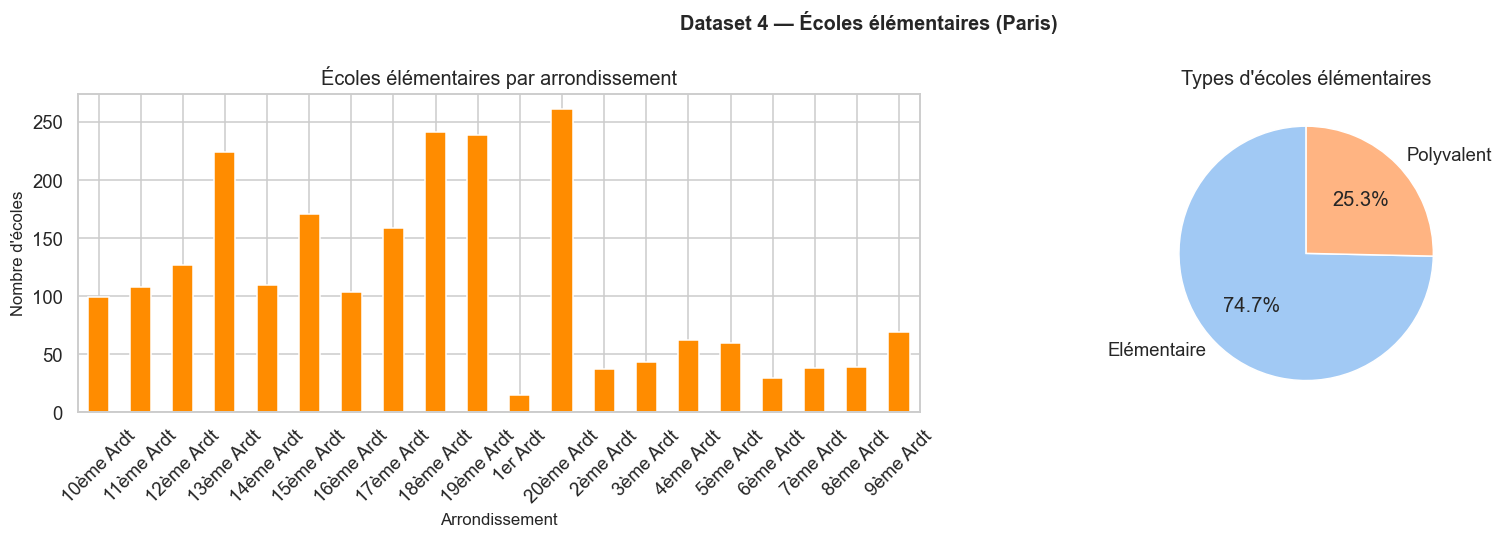

Nombre total d'écoles élémentaires : 2237
Arrondissements couverts : 20
Années scolaires présentes : ['2021-2022', '2022-2023', '2023-2024', '2024-2025', '2025-2026', '2026-2027']


In [ ]:
# ── Répartition par arrondissement et type ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

arr_counts = df_ecoles_elem['arr_libelle'].value_counts().sort_index()
arr_counts.plot(kind='bar', ax=axes[0], color='darkorange', edgecolor='white')
axes[0].set_title('Écoles élémentaires par arrondissement')
axes[0].set_xlabel('Arrondissement')
axes[0].set_ylabel('Nombre d\'écoles')
axes[0].tick_params(axis='x', rotation=45)

type_counts = df_ecoles_elem['type_etabl'].value_counts()
type_counts.plot(kind='pie', ax=axes[1], autopct='%1.1f%%',
                 colors=sns.color_palette('pastel'), startangle=90)
axes[1].set_title('Types d\'écoles élémentaires')
axes[1].set_ylabel('')

plt.suptitle('Dataset 4 — Écoles élémentaires (Paris)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Nombre total d\'écoles élémentaires : {len(df_ecoles_elem)}')
print(f'Arrondissements couverts : {df_ecoles_elem["arr_libelle"].nunique()}')
print(f'Années scolaires présentes : {sorted(df_ecoles_elem["annee_scol"].dropna().unique())}')

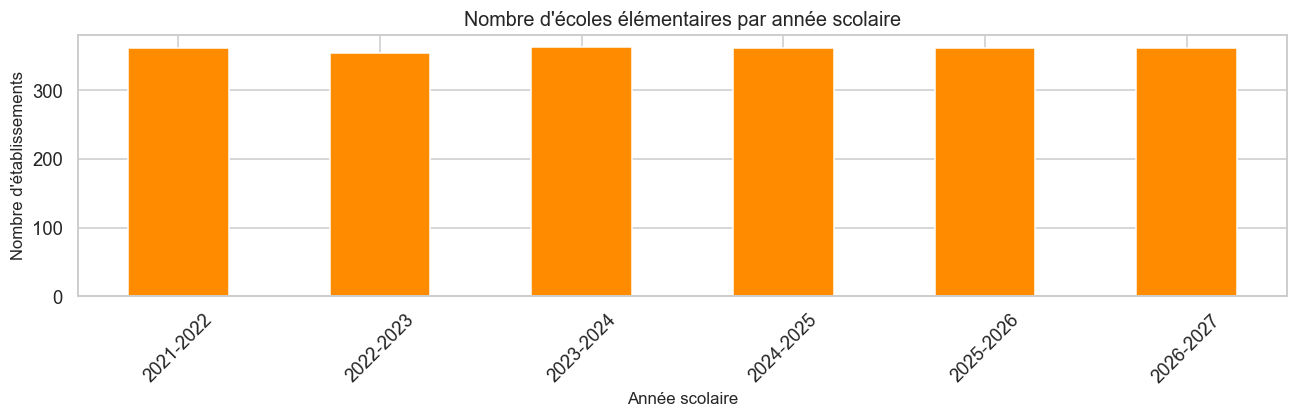

In [ ]:
# ── Évolution du nombre d'écoles par année scolaire ───────────────────────────
if df_ecoles_elem['annee_scol'].nunique() > 1:
    annee_counts = df_ecoles_elem.groupby('annee_scol').size()
    fig, ax = plt.subplots(figsize=(12, 4))
    annee_counts.plot(kind='bar', ax=ax, color='darkorange', edgecolor='white')
    ax.set_title('Nombre d\'écoles élémentaires par année scolaire')
    ax.set_xlabel('Année scolaire')
    ax.set_ylabel('Nombre d\'établissements')
    ax.tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print(f'Une seule année scolaire : {df_ecoles_elem["annee_scol"].unique()[0]}')

In [ ]:
# ── Distribution géographique ─────────────────────────────────────────────────
def extract_geo_point(series):
    """Extrait lat/lon depuis une colonne geo_point_2d de type dict ou string."""
    if series.dtype == object:
        try:
            coords = series.apply(lambda x: x if isinstance(x, dict) else {})
            lat = coords.apply(lambda x: x.get('lat', np.nan))
            lon = coords.apply(lambda x: x.get('lon', np.nan))
            return lat, lon
        except Exception:
            pass
    return None, None

lat_e, lon_e = extract_geo_point(df_ecoles_elem['geo_point_2d'])
if lat_e is not None and lat_e.notna().sum() > 0:
    fig, ax = plt.subplots(figsize=(8, 7))
    ax.scatter(lon_e, lat_e, c='darkorange', s=8, alpha=0.4, edgecolors='none')
    ax.set_title('Distribution géographique — Écoles élémentaires (Paris)')
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    plt.tight_layout()
    plt.show()
else:
    print('geo_point_2d — aperçu :')
    print(df_ecoles_elem['geo_point_2d'].head(3))

geo_point_2d — aperçu :
0    b'\x01\x01\x00\x00\x00\x9e\xd5`Z\x16\x97\x02@6...
1    b'\x01\x01\x00\x00\x00%\x18\x0e\xeb\xd1;\x03@\...
2    b'\x01\x01\x00\x00\x00\x9c\xbb\xb5F\x1ev\x02@\...
Name: geo_point_2d, dtype: object


---
## 7. Dataset 5 — Postes publics des bibliothèques

**Service public couvert :** Culture & accès numérique  
**Périmètre géographique :** Paris

In [ ]:
print('=== INFORMATIONS GÉNÉRALES ===')
print(f'Dimensions : {df_biblio.shape[0]} lignes × {df_biblio.shape[1]} colonnes')
print('\nColonnes et types :')
print(df_biblio.dtypes)
print('\n--- Aperçu ---')
display(df_biblio.head())

=== INFORMATIONS GÉNÉRALES ===
Dimensions : 266 lignes × 4 colonnes

Colonnes et types :
localisation               str
type_de_poste              str
nombre_d_ordinateurs     int64
position                object
dtype: object

--- Aperçu ---


,localisation,type_de_poste,nombre_d_ordinateurs,position
0,Georges Brassens,Poste de passage Adulte,2,"b'\x01\x01\x00\x00\x00\xc9""\xa8uv\x9d\x02@\xce..."
1,Germaine Tillion,Poste Adulte,10,"b""\x01\x01\x00\x00\x00-\x11^q'G\x02@N\x88o\x17..."
2,Vandamme,Poste Jeunesse,3,b'\x01\x01\x00\x00\x00\xe0|\x8f\x9f2\x93\x02@J...
3,Germaine Tillion,Poste Jeunesse,4,"b""\x01\x01\x00\x00\x00-\x11^q'G\x02@N\x88o\x17..."
4,Louise Walser-Gaillard,Poste de passage Jeunesse,1,b'\x01\x01\x00\x00\x00\x81\xaav\xf2\x8e\xa8\x0...


In [ ]:
print('=== VALEURS MANQUANTES ===')
miss = df_biblio.isnull().sum()
miss_pct = (miss / len(df_biblio) * 100).round(2)
miss_df = pd.DataFrame({'Manquants': miss, '% manquant': miss_pct}).query('Manquants > 0').sort_values('% manquant', ascending=False)
if miss_df.empty:
    print('Aucune valeur manquante.')
else:
    display(miss_df)

print(f'\n=== DOUBLONS ===')
print(f'Lignes dupliquées : {df_biblio.duplicated().sum()}')

=== VALEURS MANQUANTES ===
Aucune valeur manquante.

=== DOUBLONS ===
Lignes dupliquées : 0


In [ ]:
print('=== STATISTIQUES DESCRIPTIVES ===')
display(df_biblio.describe(include='all'))

=== STATISTIQUES DESCRIPTIVES ===


,localisation,type_de_poste,nombre_d_ordinateurs,position
count,266,266,266.0000,266
unique,72,10,NaN,67
top,L'Heure Joyeuse,Catalogue,NaN,b'\x01\x01\x00\x00\x00\x15\xad\xdc\x0b\xcc\xfa...
freq,6,70,NaN,8
mean,NaN,NaN,3.8534,NaN
std,NaN,NaN,3.4451,NaN
min,NaN,NaN,1.0000,NaN
25%,NaN,NaN,1.0000,NaN
50%,NaN,NaN,3.0000,NaN
75%,NaN,NaN,5.0000,NaN


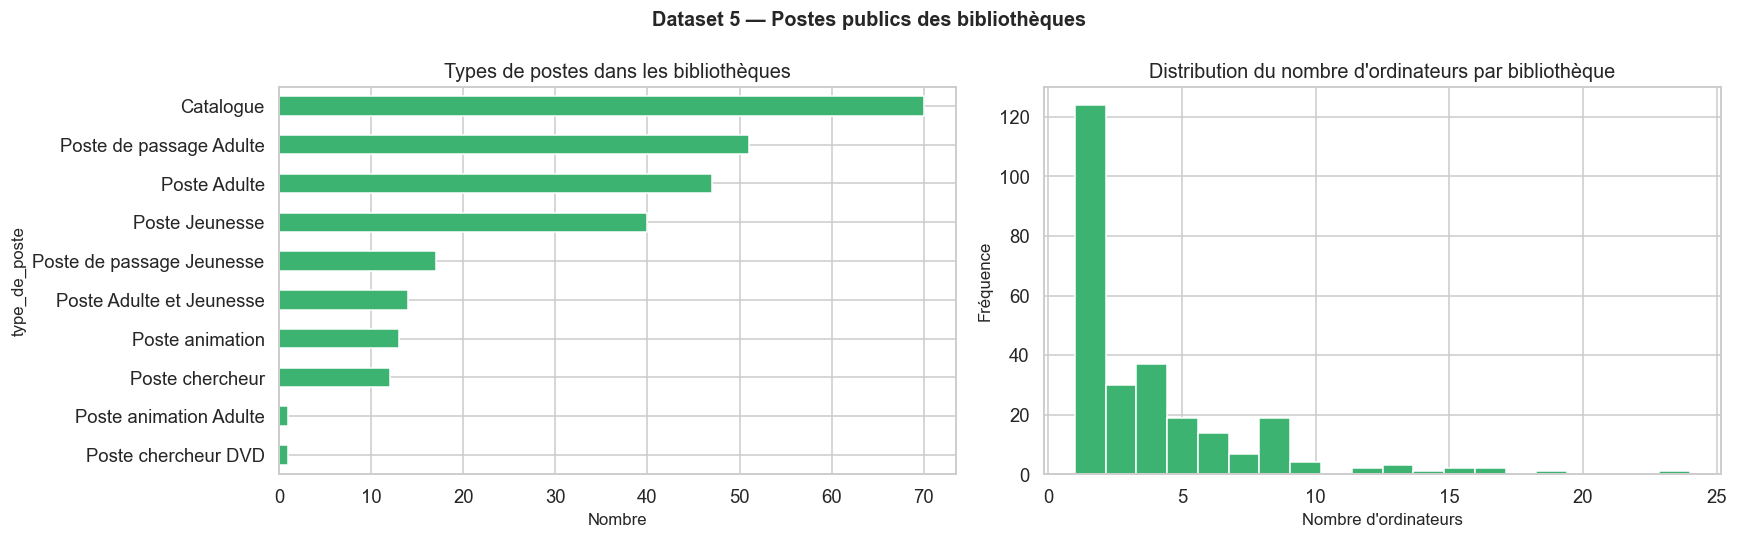

Nombre total de bibliothèques/sites : 266
Types de postes distincts : 10
Nombre total d'ordinateurs publics : 1025


In [ ]:
# ── Analyse des postes publics bibliothèques ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

type_poste = df_biblio['type_de_poste'].value_counts()
type_poste.plot(kind='barh', ax=axes[0], color='mediumseagreen', edgecolor='white')
axes[0].set_title('Types de postes dans les bibliothèques')
axes[0].set_xlabel('Nombre')
axes[0].invert_yaxis()

nb_ordi = df_biblio['nombre_d_ordinateurs'].dropna()
nb_ordi.plot(kind='hist', bins=20, ax=axes[1], color='mediumseagreen', edgecolor='white')
axes[1].set_title('Distribution du nombre d\'ordinateurs par bibliothèque')
axes[1].set_xlabel('Nombre d\'ordinateurs')
axes[1].set_ylabel('Fréquence')

plt.suptitle('Dataset 5 — Postes publics des bibliothèques', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Nombre total de bibliothèques/sites : {len(df_biblio)}')
print(f'Types de postes distincts : {df_biblio["type_de_poste"].nunique()}')
print(f'Nombre total d\'ordinateurs publics : {df_biblio["nombre_d_ordinateurs"].sum():.0f}')

---
## 8. Dataset 6 — Secteurs scolaires — Collèges

**Service public couvert :** Éducation secondaire (1er cycle)  
**Périmètre géographique :** Paris

In [ ]:
print('=== INFORMATIONS GÉNÉRALES ===')
print(f'Dimensions : {df_colleges.shape[0]} lignes × {df_colleges.shape[1]} colonnes')
print('\nColonnes et types :')
print(df_colleges.dtypes)
print('\n--- Aperçu ---')
display(df_colleges.head())

=== INFORMATIONS GÉNÉRALES ===
Dimensions : 770 lignes × 18 colonnes

Colonnes et types :
id_projet                 str
libelle                   str
annee_scol                str
zone_commune            int64
etiquette                 str
lib_etab_1                str
lib_etab_2                str
lib_etab_3                str
lib_etab_4                str
adr_etab_1                str
adr_etab_2                str
adr_etab_3                str
adr_etab_4                str
st_area_shape         float64
st_perimeter_shape    float64
type_etabl                str
geo_shape              object
geo_point_2d           object
dtype: object

--- Aperçu ---


,id_projet,libelle,annee_scol,zone_commune,etiquette,lib_etab_1,lib_etab_2,lib_etab_3,lib_etab_4,adr_etab_1,adr_etab_2,adr_etab_3,adr_etab_4,st_area_shape,st_perimeter_shape,type_etabl,geo_shape,geo_point_2d
0,COLLEGES (année scolaire 2020/2021),AIME CESAIRE,2020-2021,0,Secteur du collège AIME CESAIRE,AIME CESAIRE,NaN,NaN,NaN,22 RUE PAJOL,NaN,NaN,NaN,334450.9730,11538.9873,Collège,b'\x01\x06\x00\x00\x00\x1c\x00\x00\x00\x01\x03...,b'\x01\x01\x00\x00\x00\xf3\x00\x89\x1b\xf8\xe7...
1,COLLEGES (année scolaire 2020/2021),MOZART,2020-2021,0,Secteur du collège MOZART,MOZART,NaN,NaN,NaN,7 RUE JOMARD,NaN,NaN,NaN,202689.7028,7404.3677,Collège,b'\x01\x06\x00\x00\x00\x10\x00\x00\x00\x01\x03...,"b'\x01\x01\x00\x00\x00\x0e%""\x05\n\x0b\x03@\x8..."
2,COLLEGES (année scolaire 2020/2021),GUILLAUME BUDE,2020-2021,0,Secteur du collège GUILLAUME BUDE,GUILLAUME BUDE,NaN,NaN,NaN,7 RUE JEAN QUARRE,NaN,NaN,NaN,358783.0255,14342.7771,Collège,b'\x01\x06\x00\x00\x00\x1f\x00\x00\x00\x01\x03...,b'\x01\x01\x00\x00\x00\\^\x03\xdb;3\x03@\xbb3~...
3,COLLEGES (année scolaire 2020/2021),CESAR FRANCK,2020-2021,0,Secteur du collège CESAR FRANCK,CESAR FRANCK,NaN,NaN,NaN,5 RUE DE LA JUSSIENNE,NaN,NaN,NaN,356767.3904,21156.2758,Collège,b'\x01\x06\x00\x00\x00I\x00\x00\x00\x01\x03\x0...,b'\x01\x01\x00\x00\x00>i[\x06\x8d\xc2\x02@k\x8...
4,COLLEGES (année scolaire 2020/2021),HONORE DE BALZAC,2020-2021,0,Secteur du collège HONORE DE BALZAC,HONORE DE BALZAC,NaN,NaN,NaN,118 BOULEVARD BESSIERES,NaN,NaN,NaN,569194.0323,19980.9722,Collège,b'\x01\x06\x00\x00\x00\'\x00\x00\x00\x01\x03\x...,b'\x01\x01\x00\x00\x00\xe5v\x94\x88\x0b\x8d\x0...


In [ ]:
print('=== VALEURS MANQUANTES ===')
miss = df_colleges.isnull().sum()
miss_pct = (miss / len(df_colleges) * 100).round(2)
miss_df = pd.DataFrame({'Manquants': miss, '% manquant': miss_pct}).query('Manquants > 0').sort_values('% manquant', ascending=False)
if miss_df.empty:
    print('Aucune valeur manquante.')
else:
    display(miss_df)

print(f'\n=== DOUBLONS ===')
print(f'Lignes dupliquées : {df_colleges.duplicated().sum()}')

=== VALEURS MANQUANTES ===


,Manquants,% manquant
lib_etab_3,770,100.0000
lib_etab_4,770,100.0000
adr_etab_4,770,100.0000
adr_etab_3,770,100.0000
lib_etab_2,749,97.2700
adr_etab_2,749,97.2700
adr_etab_1,24,3.1200



=== DOUBLONS ===
Lignes dupliquées : 0


In [ ]:
print('=== STATISTIQUES DESCRIPTIVES ===')
display(df_colleges.describe(include='all'))

=== STATISTIQUES DESCRIPTIVES ===


,id_projet,libelle,annee_scol,zone_commune,etiquette,lib_etab_1,lib_etab_2,lib_etab_3,lib_etab_4,adr_etab_1,adr_etab_2,adr_etab_3,adr_etab_4,st_area_shape,st_perimeter_shape,type_etabl,geo_shape,geo_point_2d
count,770,770,770,770.0000,770,770,21,0,0,746,21,0,0,770.0000,770.0000,770,770,770
unique,7,114,7,NaN,110,110,3,0,0,111,3,0,0,NaN,NaN,1,488,488
top,COLLEGES (année scolaire 2020/2021),AIME CESAIRE,2020-2021,NaN,Secteur du collège AIME CESAIRE,AIME CESAIRE,EDOUARD PAILLERON,NaN,NaN,22 RUE PAJOL,35 RUE EDOUARD PAILLERON,NaN,NaN,NaN,NaN,Collège,b'\x01\x06\x00\x00\x00\x1c\x00\x00\x00\x01\x03...,b'\x01\x01\x00\x00\x00\xf3\x00\x89\x1b\xf8\xe7...
freq,110,7,110,NaN,7,7,7,NaN,NaN,7,7,NaN,NaN,NaN,NaN,770,3,3
mean,NaN,NaN,NaN,0.0273,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,582154.1888,23156.1260,NaN,NaN,NaN
std,NaN,NaN,NaN,0.1630,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,561142.4017,13495.9691,NaN,NaN,NaN
min,NaN,NaN,NaN,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,135698.8991,6737.3214,NaN,NaN,NaN
25%,NaN,NaN,NaN,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,338182.3924,14918.9781,NaN,NaN,NaN
50%,NaN,NaN,NaN,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,483800.5368,21080.4935,NaN,NaN,NaN
75%,NaN,NaN,NaN,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,665768.6506,26804.1175,NaN,NaN,NaN


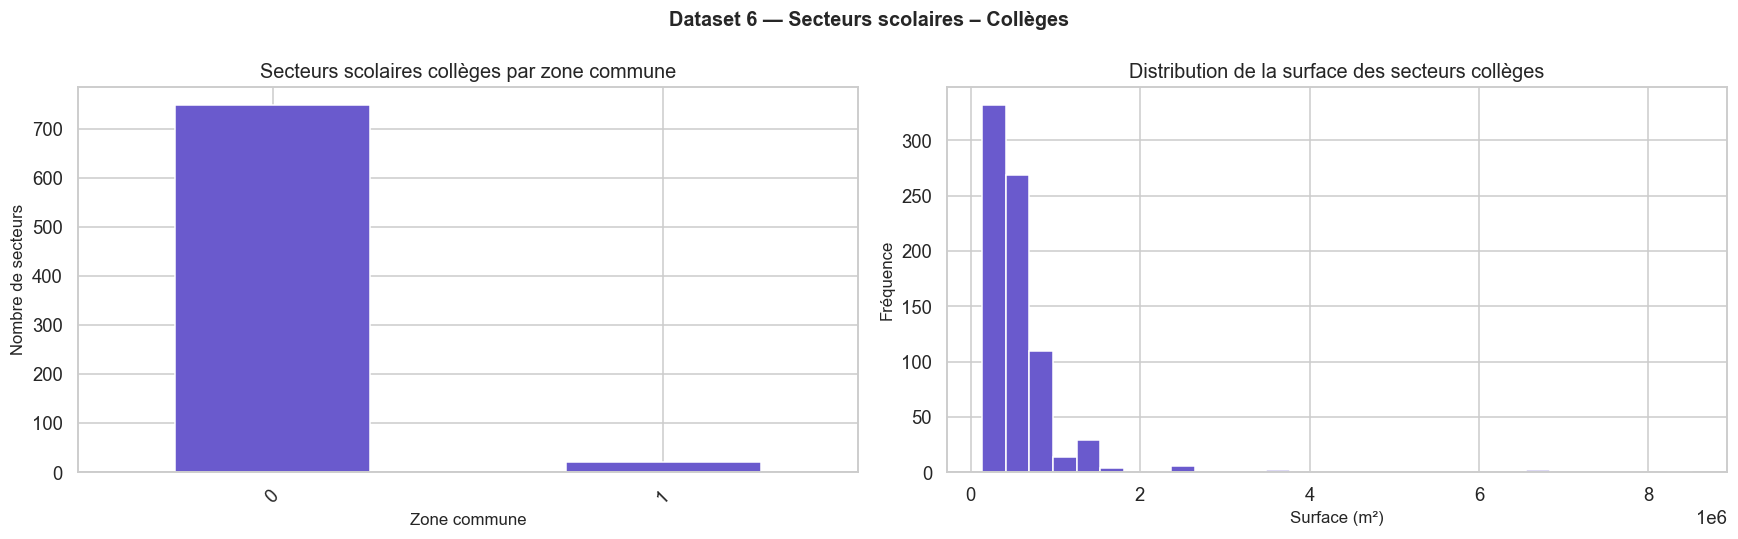

Nombre total de secteurs : 770
Zones communes distinctes : 2
Collèges distincts (lib_etab_1) : 110
Années scolaires : ['2020-2021', '2021-2022', '2022-2023', '2023-2024', '2024-2025', '2025-2026', '2026-2027']


In [ ]:
# ── Analyse des secteurs collèges ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

zone_counts = df_colleges['zone_commune'].value_counts().sort_index()
zone_counts.plot(kind='bar', ax=axes[0], color='slateblue', edgecolor='white')
axes[0].set_title('Secteurs scolaires collèges par zone commune')
axes[0].set_xlabel('Zone commune')
axes[0].set_ylabel('Nombre de secteurs')
axes[0].tick_params(axis='x', rotation=45)

# Surface des secteurs
area_data = df_colleges['st_area_shape'].dropna()
area_data.plot(kind='hist', bins=30, ax=axes[1], color='slateblue', edgecolor='white')
axes[1].set_title('Distribution de la surface des secteurs collèges')
axes[1].set_xlabel('Surface (m²)')
axes[1].set_ylabel('Fréquence')

plt.suptitle('Dataset 6 — Secteurs scolaires – Collèges', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Nombre total de secteurs : {len(df_colleges)}')
print(f'Zones communes distinctes : {df_colleges["zone_commune"].nunique()}')
print(f'Collèges distincts (lib_etab_1) : {df_colleges["lib_etab_1"].nunique()}')
print(f'Années scolaires : {sorted(df_colleges["annee_scol"].dropna().unique())}')

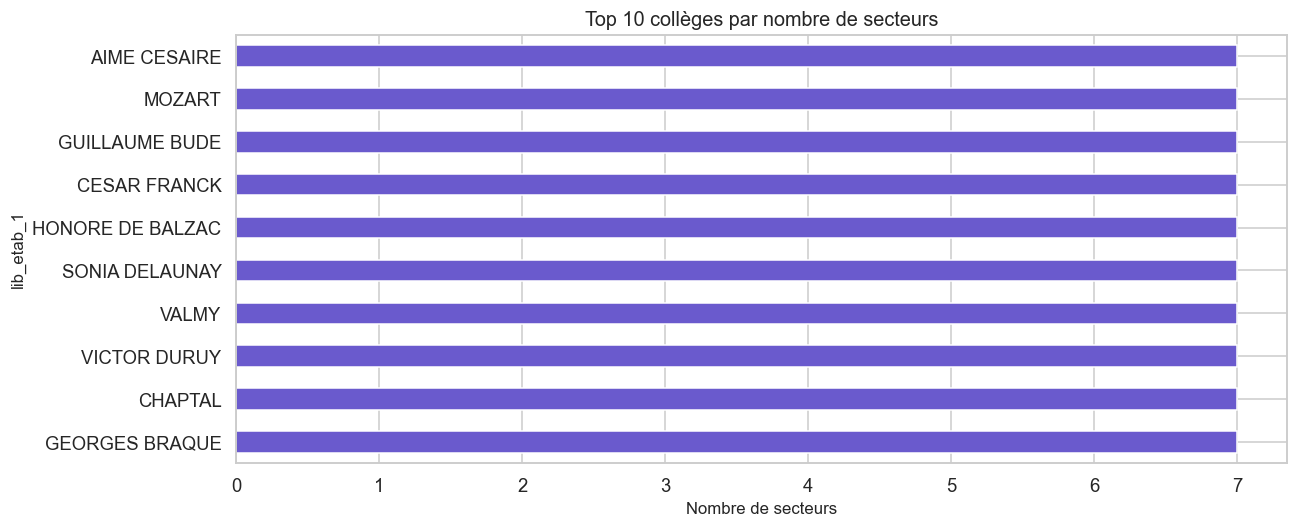

In [ ]:
# ── Top 10 collèges par nombre de secteurs ────────────────────────────────────
top_colleges = df_colleges['lib_etab_1'].value_counts().head(10)
fig, ax = plt.subplots(figsize=(12, 5))
top_colleges.plot(kind='barh', ax=ax, color='slateblue', edgecolor='white')
ax.set_title('Top 10 collèges par nombre de secteurs')
ax.set_xlabel('Nombre de secteurs')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

---
## 9. Dataset 7 — Secteurs scolaires — Maternelles

**Service public couvert :** Petite enfance (éducation préscolaire)  
**Périmètre géographique :** Paris

In [ ]:
print('=== INFORMATIONS GÉNÉRALES ===')
print(f'Dimensions : {df_maternelles.shape[0]} lignes × {df_maternelles.shape[1]} colonnes')
print('\nColonnes et types :')
print(df_maternelles.dtypes)
print('\n--- Aperçu ---')
display(df_maternelles.head())

=== INFORMATIONS GÉNÉRALES ===
Dimensions : 2683 lignes × 18 colonnes

Colonnes et types :
id_projet                 str
libelle                   str
annee_scol                str
zone_commune            int64
etiquette                 str
lib_etab_1                str
lib_etab_2                str
lib_etab_3                str
lib_etab_4                str
adr_etab_1                str
adr_etab_2                str
adr_etab_3                str
adr_etab_4                str
type_etabl                str
geo_shape              object
geo_point_2d           object
st_area_shape         float64
st_perimeter_shape    float64
dtype: object

--- Aperçu ---


,id_projet,libelle,annee_scol,zone_commune,etiquette,lib_etab_1,lib_etab_2,lib_etab_3,lib_etab_4,adr_etab_1,adr_etab_2,adr_etab_3,adr_etab_4,type_etabl,geo_shape,geo_point_2d,st_area_shape,st_perimeter_shape
0,MATERNELLES (année scolaire 2020/2021),BIDASSOA (21) MAT,2020-2021,0,Secteur de l'école 21 RUE DE LA BIDASSOA,BIDASSOA (21) MAT,NaN,NaN,NaN,21 RUE DE LA BIDASSOA,NaN,NaN,NaN,NaN,b'\x01\x06\x00\x00\x00\x14\x00\x00\x00\x01\x03...,b'\x01\x01\x00\x00\x00B\xd1\x07;G(\x03@\xd5\x8...,97985.3873,6580.1435
1,MATERNELLES (année scolaire 2020/2021),JEAN MENANS (2) MAT,2020-2021,0,Secteur de l'école 2 RUE JEAN MENANS,JEAN MENANS (2) MAT,NaN,NaN,NaN,2 RUE JEAN MENANS,NaN,NaN,NaN,NaN,b'\x01\x06\x00\x00\x00\x0b\x00\x00\x00\x01\x03...,b'\x01\x01\x00\x00\x00!\xe8\x844\xb9\t\x03@\xf...,80302.9670,5163.0356
2,MATERNELLES (année scolaire 2020/2021),ROQUETTE (144) MAT,2020-2021,0,Secteur de l'école 144 RUE DE LA ROQUETTE,ROQUETTE (144) MAT,NaN,NaN,NaN,144 RUE DE LA ROQUETTE,NaN,NaN,NaN,NaN,b'\x01\x06\x00\x00\x00\x1c\x00\x00\x00\x01\x03...,b'\x01\x01\x00\x00\x00.\x8d\xb0\xa9v\x12\x03@W...,109981.7944,7417.0702
3,MATERNELLES (année scolaire 2020/2021),PERLE (7) MAT,2020-2021,0,Secteur de l'école 7 RUE DE LA PERLE,PERLE (7) MAT,NaN,NaN,NaN,7 RUE DE LA PERLE,NaN,NaN,NaN,NaN,b'\x01\x06\x00\x00\x00\x1b\x00\x00\x00\x01\x03...,b'\x01\x01\x00\x00\x00\x1c\r\x12\xf7\xe4\xe1\x...,256477.8192,11474.5638
4,MATERNELLES (année scolaire 2020/2021),JEANNE D'ARC (32) MAT,2020-2021,0,Secteur de l'école 32 PLACE JEANNE D'ARC,JEANNE D'ARC (32) MAT,NaN,NaN,NaN,32 PLACE JEANNE D'ARC,NaN,NaN,NaN,NaN,b'\x01\x06\x00\x00\x00\t\x00\x00\x00\x01\x03\x...,b'\x01\x01\x00\x00\x00&\xfe4\xba\xd6\xf4\x02@Z...,53089.5440,3712.6340


In [ ]:
print('=== VALEURS MANQUANTES ===')
miss = df_maternelles.isnull().sum()
miss_pct = (miss / len(df_maternelles) * 100).round(2)
miss_df = pd.DataFrame({'Manquants': miss, '% manquant': miss_pct}).query('Manquants > 0').sort_values('% manquant', ascending=False)
if miss_df.empty:
    print('Aucune valeur manquante.')
else:
    display(miss_df)

print(f'\n=== DOUBLONS ===')
print(f'Lignes dupliquées : {df_maternelles.duplicated().sum()}')

=== VALEURS MANQUANTES ===


,Manquants,% manquant
lib_etab_4,2655,98.9600
adr_etab_4,2655,98.9600
adr_etab_3,2573,95.9000
lib_etab_3,2572,95.8600
adr_etab_2,2362,88.0400
lib_etab_2,2361,88.0000
type_etabl,384,14.3100
adr_etab_1,59,2.2000
lib_etab_1,3,0.1100



=== DOUBLONS ===
Lignes dupliquées : 0


In [ ]:
print('=== STATISTIQUES DESCRIPTIVES ===')
display(df_maternelles.describe(include='all'))

=== STATISTIQUES DESCRIPTIVES ===


,id_projet,libelle,annee_scol,zone_commune,etiquette,lib_etab_1,lib_etab_2,lib_etab_3,lib_etab_4,adr_etab_1,adr_etab_2,adr_etab_3,adr_etab_4,type_etabl,geo_shape,geo_point_2d,st_area_shape,st_perimeter_shape
count,2683,2683,2683,2683.0000,2683,2680,322,111,28,2624,321,110,28,2299,2683,2683,2683.0000,2683.0000
unique,7,490,7,NaN,859,409,86,29,5,732,123,42,6,1,1420,1408,NaN,NaN
top,MATERNELLES (année scolaire 2025/2026),BIDASSOA (21) MAT,2025-2026,NaN,Secteur de l'école,CHARLES BAUDELAIRE (16) MAT,JEAN BOUTON (7) MAT,TRAVERSIERE (41) MAT,DAUMESNIL (70) MAT,16 RUE CHARLES BAUDELAIRE,7 RUE JEAN BOUTON,41 RUE TRAVERSIERE,70 AVENUE DAUMESNIL,Maternelle,b'\x01\x03\x00\x00\x00\x01\x00\x00\x00\x05\x00...,b'\x01\x01\x00\x00\x00\x1d\x94\xe4I\x03%\x03@\...,NaN,NaN
freq,393,7,393,NaN,57,26,19,12,13,24,18,12,12,2299,7,7,NaN,NaN
mean,NaN,NaN,NaN,0.1196,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,163556.6807,7107.3092
std,NaN,NaN,NaN,0.3246,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,280870.5706,5087.9777
min,NaN,NaN,NaN,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.7820,8.0311
25%,NaN,NaN,NaN,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,77967.3121,4357.8912
50%,NaN,NaN,NaN,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,125187.2576,6434.1560
75%,NaN,NaN,NaN,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,189990.4961,8937.4322


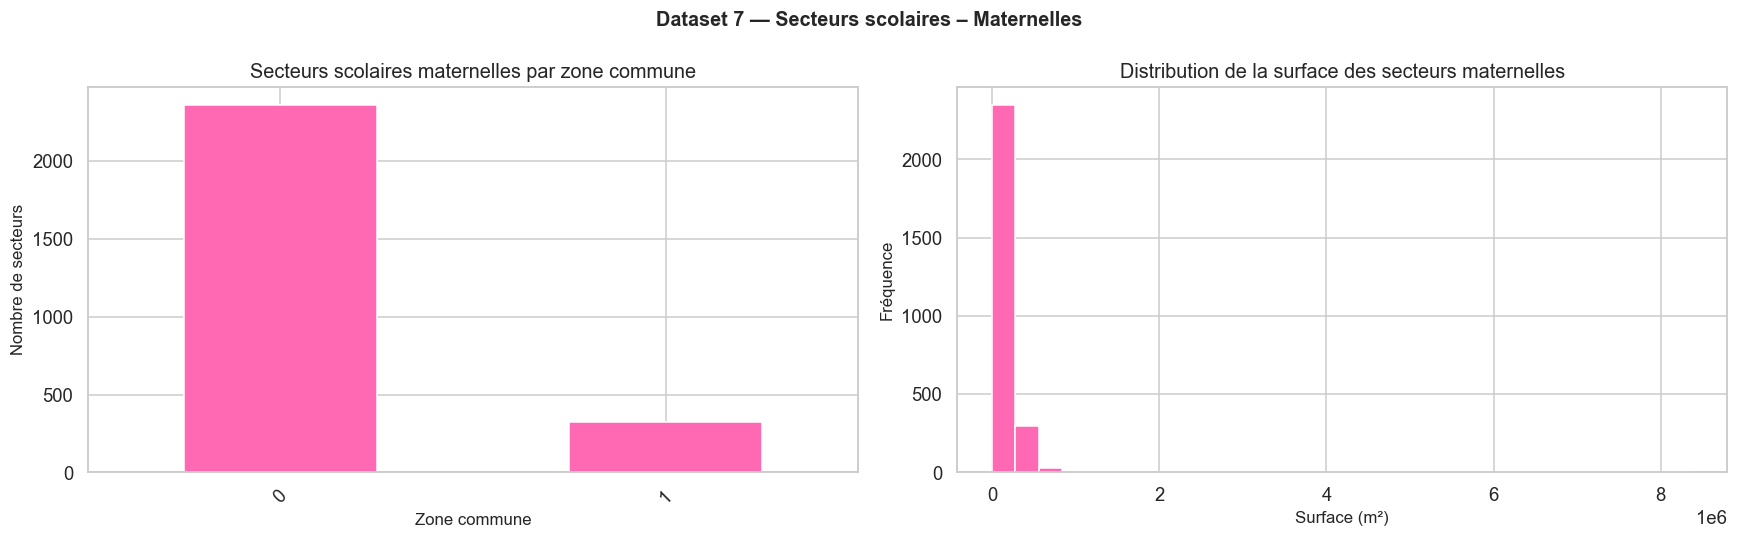

Nombre total de secteurs : 2683
Zones communes distinctes : 2
Maternelles distinctes (lib_etab_1) : 409
Années scolaires : ['2020-2021', '2021-2022', '2022-2023', '2023-2024', '2024-2025', '2025-2026', '2026-2027']


In [ ]:
# ── Analyse des secteurs maternelles ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

zone_counts_m = df_maternelles['zone_commune'].value_counts().sort_index()
zone_counts_m.plot(kind='bar', ax=axes[0], color='hotpink', edgecolor='white')
axes[0].set_title('Secteurs scolaires maternelles par zone commune')
axes[0].set_xlabel('Zone commune')
axes[0].set_ylabel('Nombre de secteurs')
axes[0].tick_params(axis='x', rotation=45)

# Surface des secteurs
area_data_m = df_maternelles['st_area_shape'].dropna()
area_data_m.plot(kind='hist', bins=30, ax=axes[1], color='hotpink', edgecolor='white')
axes[1].set_title('Distribution de la surface des secteurs maternelles')
axes[1].set_xlabel('Surface (m²)')
axes[1].set_ylabel('Fréquence')

plt.suptitle('Dataset 7 — Secteurs scolaires – Maternelles', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Nombre total de secteurs : {len(df_maternelles)}')
print(f'Zones communes distinctes : {df_maternelles["zone_commune"].nunique()}')
print(f'Maternelles distinctes (lib_etab_1) : {df_maternelles["lib_etab_1"].nunique()}')
print(f'Années scolaires : {sorted(df_maternelles["annee_scol"].dropna().unique())}')

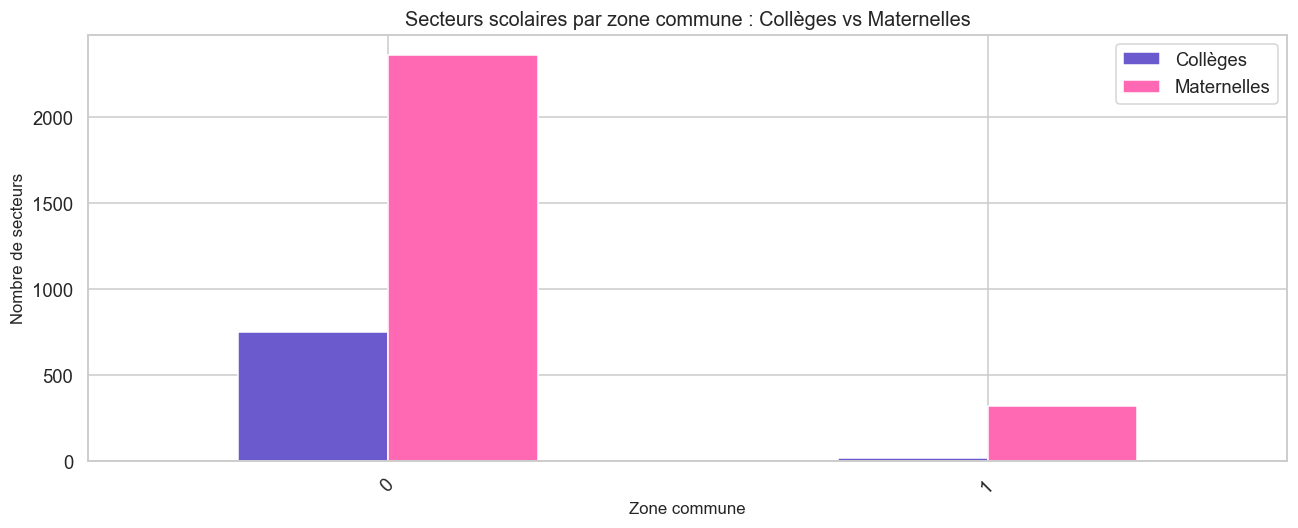

In [ ]:
# ── Comparaison collèges vs maternelles ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))

# Secteurs par zone commune
comp_data = pd.DataFrame({
    'Collèges': df_colleges['zone_commune'].value_counts(),
    'Maternelles': df_maternelles['zone_commune'].value_counts()
}).fillna(0)

comp_data.plot(kind='bar', ax=ax, color=['slateblue', 'hotpink'], edgecolor='white')
ax.set_title('Secteurs scolaires par zone commune : Collèges vs Maternelles')
ax.set_xlabel('Zone commune')
ax.set_ylabel('Nombre de secteurs')
ax.tick_params(axis='x', rotation=45)
ax.legend()
plt.tight_layout()
plt.show()

---
## 10. Analyse transversale — Couverture territoriale

Cette section compare la densité d'offre de services publics entre les différents territoires couverts par les datasets.

In [ ]:
# ── Synthèse des volumes par service ─────────────────────────────────────────
synthese = pd.DataFrame([
    {'Service': 'Police (accueil)', 'Périmètre': 'Paris', 'Nb établissements': len(df_police),
     'Nb coordonnées GPS': df_police['WGS84'].notna().sum(), '% géocodé': round(df_police['WGS84'].notna().sum()/len(df_police)*100,1)},
    {'Service': 'Hôpitaux', 'Périmètre': 'IDF', 'Nb établissements': len(df_hopitaux),
     'Nb coordonnées GPS': df_hopitaux['lat'].notna().sum(), '% géocodé': round(df_hopitaux['lat'].notna().sum()/len(df_hopitaux)*100,1)},
    {'Service': 'Bureaux de poste', 'Périmètre': 'IDF', 'Nb établissements': len(df_poste),
     'Nb coordonnées GPS': df_poste['latitude'].notna().sum(), '% géocodé': round(df_poste['latitude'].notna().sum()/len(df_poste)*100,1)},
    {'Service': 'Écoles élémentaires', 'Périmètre': 'Paris', 'Nb établissements': len(df_ecoles_elem),
     'Nb coordonnées GPS': df_ecoles_elem['geo_point_2d'].notna().sum(), '% géocodé': round(df_ecoles_elem['geo_point_2d'].notna().sum()/len(df_ecoles_elem)*100,1)},
    {'Service': 'Bibliothèques (postes)', 'Périmètre': 'Paris', 'Nb établissements': len(df_biblio),
     'Nb coordonnées GPS': df_biblio['position'].notna().sum(), '% géocodé': round(df_biblio['position'].notna().sum()/len(df_biblio)*100,1)},
    {'Service': 'Secteurs collèges', 'Périmètre': 'Paris', 'Nb établissements': len(df_colleges),
     'Nb coordonnées GPS': df_colleges['geo_point_2d'].notna().sum(), '% géocodé': round(df_colleges['geo_point_2d'].notna().sum()/len(df_colleges)*100,1)},
    {'Service': 'Secteurs maternelles', 'Périmètre': 'Paris', 'Nb établissements': len(df_maternelles),
     'Nb coordonnées GPS': df_maternelles['geo_point_2d'].notna().sum(), '% géocodé': round(df_maternelles['geo_point_2d'].notna().sum()/len(df_maternelles)*100,1)},
])

display(synthese.set_index('Service').style
        .background_gradient(subset=['% géocodé'], cmap='Greens')
        .format({'% géocodé': '{:.1f}%', 'Nb établissements': '{:,}', 'Nb coordonnées GPS': '{:,}'}))

,Périmètre,Nb établissements,Nb coordonnées GPS,% géocodé
Service,,,,
Police (accueil),Paris,55,55,100.0%
Hôpitaux,IDF,"1,223","1,223",100.0%
Bureaux de poste,IDF,"1,566","1,566",100.0%
Écoles élémentaires,Paris,"2,237","2,237",100.0%
Bibliothèques (postes),Paris,266,266,100.0%
Secteurs collèges,Paris,770,770,100.0%
Secteurs maternelles,Paris,"2,683","2,683",100.0%


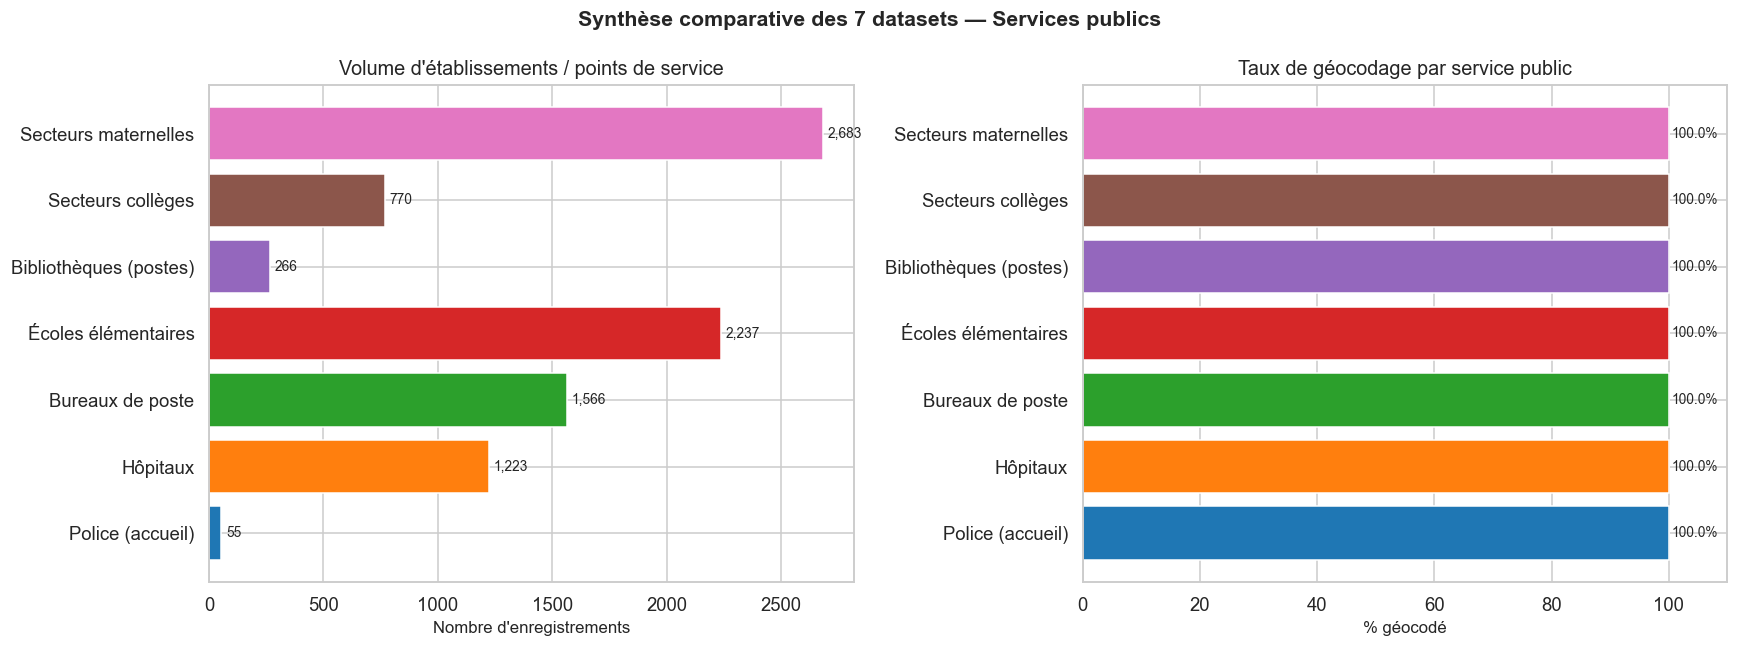

In [ ]:
# ── Visualisation comparative ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors_serv = sns.color_palette('tab10', n_colors=len(synthese))

bars = axes[0].barh(synthese['Service'], synthese['Nb établissements'], color=colors_serv)
axes[0].set_title('Volume d\'établissements / points de service')
axes[0].set_xlabel('Nombre d\'enregistrements')
for bar, v in zip(bars, synthese['Nb établissements']):
    axes[0].text(bar.get_width() + 20, bar.get_y() + bar.get_height()/2, f'{v:,}', va='center', fontsize=9)

bars2 = axes[1].barh(synthese['Service'], synthese['% géocodé'], color=colors_serv)
axes[1].set_title('Taux de géocodage par service public')
axes[1].set_xlabel('% géocodé')
axes[1].set_xlim(0, 110)
for bar, v in zip(bars2, synthese['% géocodé']):
    axes[1].text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2, f'{v:.1f}%', va='center', fontsize=9)

plt.suptitle('Synthèse comparative des 7 datasets — Services publics', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

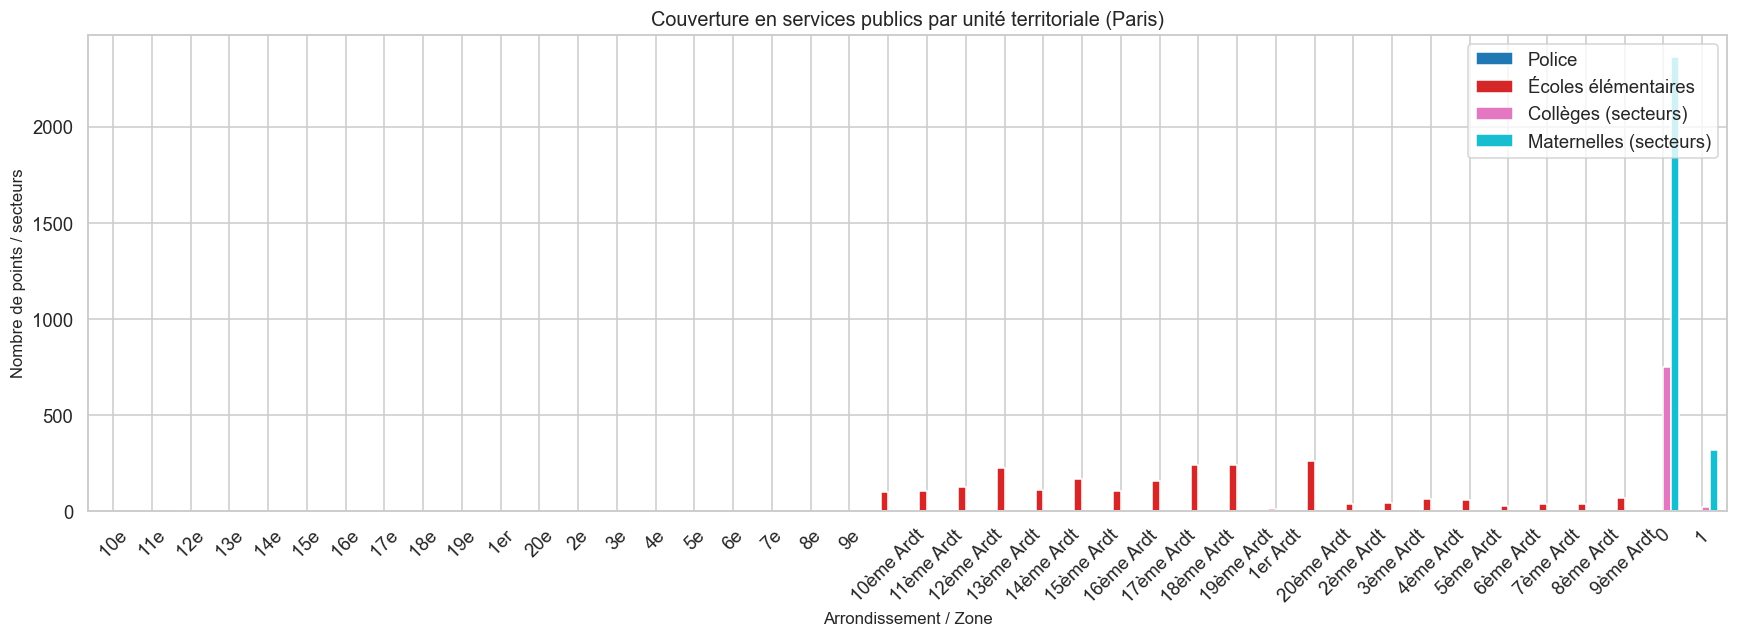

In [ ]:
# ── Couverture Paris : points de service par arrondissement ───────────────────
# Police
police_arr = df_police.groupby('ardt').size().rename('Police')

# Écoles élémentaires (par arr_libelle)
ecoles_arr = df_ecoles_elem.groupby('arr_libelle').size().rename('Écoles élémentaires')

# Collèges (par zone_commune)
colleges_arr = df_colleges.groupby('zone_commune').size().rename('Collèges (secteurs)')

# Maternelles (par zone_commune)
mat_arr = df_maternelles.groupby('zone_commune').size().rename('Maternelles (secteurs)')

# Fusion
paris_coverage = pd.concat([police_arr, ecoles_arr, colleges_arr, mat_arr], axis=1).fillna(0)

fig, ax = plt.subplots(figsize=(16, 6))
paris_coverage.plot(kind='bar', ax=ax, colormap='tab10', edgecolor='white', width=0.8)
ax.set_title('Couverture en services publics par unité territoriale (Paris)', fontsize=13)
ax.set_xlabel('Arrondissement / Zone')
ax.set_ylabel('Nombre de points / secteurs')
ax.tick_params(axis='x', rotation=45)
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

---
## 11. Construction du Score d'accès aux services publics

### Méthodologie proposée

Le **Score d'accès aux services publics** est un indicateur composite agrégé à l'arrondissement (Paris) ou au département (IDF). Il combine la densité de présence des 7 services publics, pondérée selon leur importance pour les citoyens.

| Dimension | Dataset | Pondération suggérée |
|-----------|---------|----------------------|
| Santé | Hôpitaux IDF | 25 % |
| Éducation primaire | Écoles élémentaires | 20 % |
| Petite enfance | Maternelles | 15 % |
| Éducation secondaire | Collèges | 15 % |
| Services postaux | Bureaux de poste | 10 % |
| Sécurité / accueil | Police (Paris) | 10 % |
| Culture / numérique | Bibliothèques | 5 % |

> **Note :** Ces pondérations sont indicatives et doivent être validées par des experts métier / politiques publiques.

In [ ]:
# ── Score composite (Paris — par arrondissement) ──────────────────────────────
# On normalise chaque indicateur entre 0 et 1 (min-max) avant pondération

def minmax_norm(series):
    s_min, s_max = series.min(), series.max()
    if s_max == s_min:
        return pd.Series(1.0, index=series.index)
    return (series - s_min) / (s_max - s_min)

# Agréger par arrondissement (Paris uniquement)
score_df = pd.DataFrame(index=df_ecoles_elem['arr_libelle'].unique())
score_df.index.name = 'Arrondissement'

# Écoles élémentaires
score_df['ecoles_elem'] = df_ecoles_elem.groupby('arr_libelle').size().reindex(score_df.index).fillna(0)

# Collèges (secteurs)
score_df['colleges'] = df_colleges.groupby('zone_commune').size().reindex(score_df.index).fillna(0)

# Maternelles (secteurs)
score_df['maternelles'] = df_maternelles.groupby('zone_commune').size().reindex(score_df.index).fillna(0)

# Police
score_df['police'] = df_police.groupby('ardt').size().reindex(score_df.index).fillna(0)

# Normalisation min-max
indicators = ['ecoles_elem', 'colleges', 'maternelles', 'police']
weights = {'ecoles_elem': 0.25, 'colleges': 0.20, 'maternelles': 0.20, 'police': 0.15}
# Bibliothèques et bureaux de poste non désagrégés par arr dans ce dataset → exclus ici

for col in indicators:
    score_df[f'{col}_norm'] = minmax_norm(score_df[col])

# Score composite pondéré (somme des poids = 0.80 ici, renormalisé sur 100)
total_weight = sum(weights.values())
score_df['score_acces'] = sum(
    score_df[f'{col}_norm'] * w for col, w in weights.items()
) / total_weight * 100

score_df_sorted = score_df[['ecoles_elem', 'colleges', 'maternelles', 'police', 'score_acces']].sort_values('score_acces', ascending=False)
display(score_df_sorted.style
        .background_gradient(subset=['score_acces'], cmap='RdYlGn')
        .format({'score_acces': '{:.1f}/100'}))

,ecoles_elem,colleges,maternelles,police,score_acces
Arrondissement,,,,,
20ème Ardt,261,0.000000,0.000000,0.000000,100.0/100
18ème Ardt,242,0.000000,0.000000,0.000000,97.6/100
19ème Ardt,239,0.000000,0.000000,0.000000,97.2/100
13ème Ardt,224,0.000000,0.000000,0.000000,95.3/100
15ème Ardt,171,0.000000,0.000000,0.000000,88.6/100
17ème Ardt,159,0.000000,0.000000,0.000000,87.0/100
12ème Ardt,127,0.000000,0.000000,0.000000,83.0/100
14ème Ardt,110,0.000000,0.000000,0.000000,80.8/100
11ème Ardt,108,0.000000,0.000000,0.000000,80.6/100


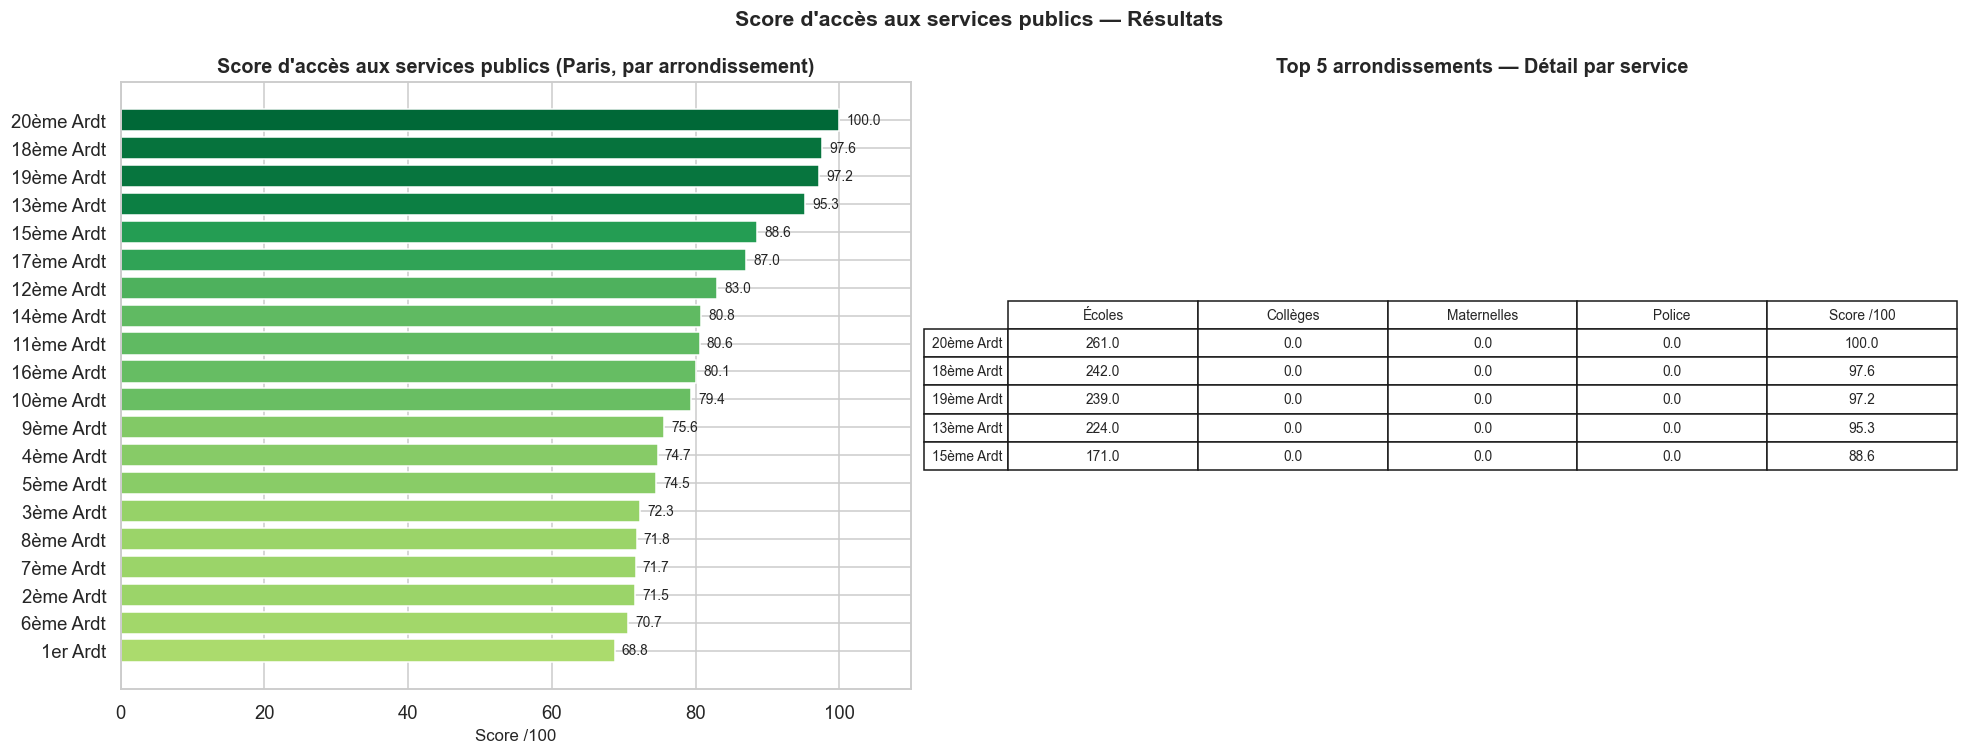

In [ ]:
# ── Visualisation du score final ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

score_sorted = score_df_sorted['score_acces'].sort_values(ascending=True)
colors_score = plt.cm.RdYlGn(score_sorted / 100)

bars = axes[0].barh(score_sorted.index, score_sorted.values, color=colors_score, edgecolor='white')
axes[0].set_title('Score d\'accès aux services publics (Paris, par arrondissement)', fontweight='bold')
axes[0].set_xlabel('Score /100')
axes[0].set_xlim(0, 110)
for bar, v in zip(bars, score_sorted.values):
    axes[0].text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2, f'{v:.1f}', va='center', fontsize=9)

# Radar chart des indicateurs pour le top 5 et bottom 5
top5 = score_df_sorted.head(5)
indicators_labels = ['Écoles élémentaires', 'Collèges', 'Maternelles', 'Police']
norm_cols = ['ecoles_elem_norm', 'colleges_norm', 'maternelles_norm', 'police_norm']

axes[1].axis('off')
table_data = top5[['ecoles_elem', 'colleges', 'maternelles', 'police', 'score_acces']].round(1)
table_data.columns = ['Écoles', 'Collèges', 'Maternelles', 'Police', 'Score /100']
table = axes[1].table(
    cellText=table_data.values,
    colLabels=table_data.columns,
    rowLabels=table_data.index,
    loc='center',
    cellLoc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1.2, 1.5)
axes[1].set_title('Top 5 arrondissements — Détail par service', fontweight='bold')

plt.suptitle('Score d\'accès aux services publics — Résultats', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

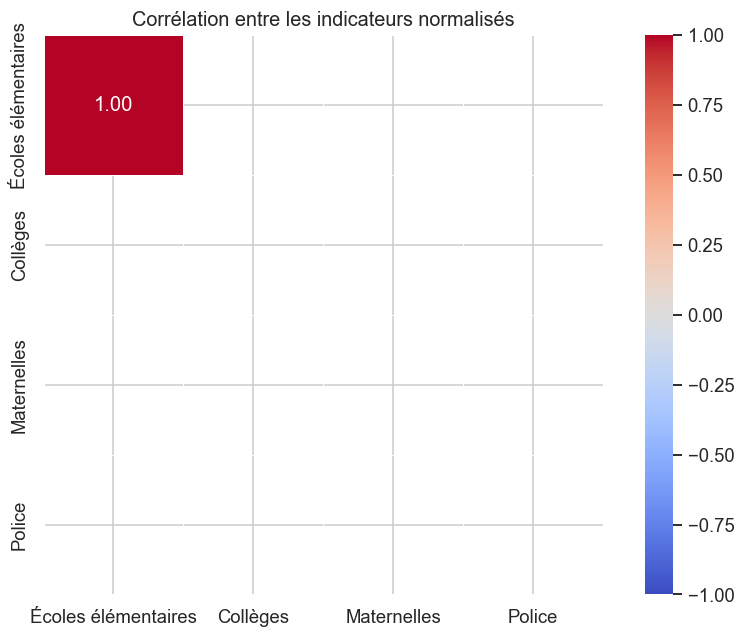

In [ ]:
# ── Matrice de corrélation entre indicateurs ──────────────────────────────────
corr_cols = ['ecoles_elem_norm', 'colleges_norm', 'maternelles_norm', 'police_norm']
corr_labels = ['Écoles élémentaires', 'Collèges', 'Maternelles', 'Police']
corr_matrix = score_df[corr_cols].rename(columns=dict(zip(corr_cols, corr_labels))).corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            vmin=-1, vmax=1, ax=ax, square=True, linewidths=0.5)
ax.set_title('Corrélation entre les indicateurs normalisés')
plt.tight_layout()
plt.show()

---
## 12. Qualité des données — Bilan global

Récapitulatif des points de vigilance identifiés lors de l'EDA.

In [ ]:
# ── Bilan qualité données ────────────────────────────────────────────────────
bilan = []
for name, df in datasets.items():
    nb_miss = df.isnull().sum().sum()
    pct_miss = nb_miss / (df.shape[0] * df.shape[1]) * 100
    nb_dupl = df.duplicated().sum()
    # Qualité globale
    if pct_miss < 5 and nb_dupl == 0:
        qualite = ' Bonne'
    elif pct_miss < 20 and nb_dupl < 10:
        qualite = ' Correcte'
    else:
        qualite = ' À améliorer'
    bilan.append({'Dataset': name, 'Lignes': df.shape[0], '% manquant': round(pct_miss, 1), 'Doublons': nb_dupl, 'Qualité globale': qualite})

bilan_df = pd.DataFrame(bilan).set_index('Dataset')
display(bilan_df)

,Lignes,% manquant,Doublons,Qualité globale
Dataset,,,,
Police (Paris),55,0.2000,0,Bonne
Hôpitaux (IDF),1223,16.7000,0,Correcte
Bureaux de poste (IDF),1566,11.5000,0,Correcte
Écoles élémentaires,2237,0.4000,0,Bonne
Bibliothèques,266,0.0000,0,Bonne
Secteurs collèges,770,33.2000,0,À améliorer
Secteurs maternelles,2683,32.4000,0,À améliorer


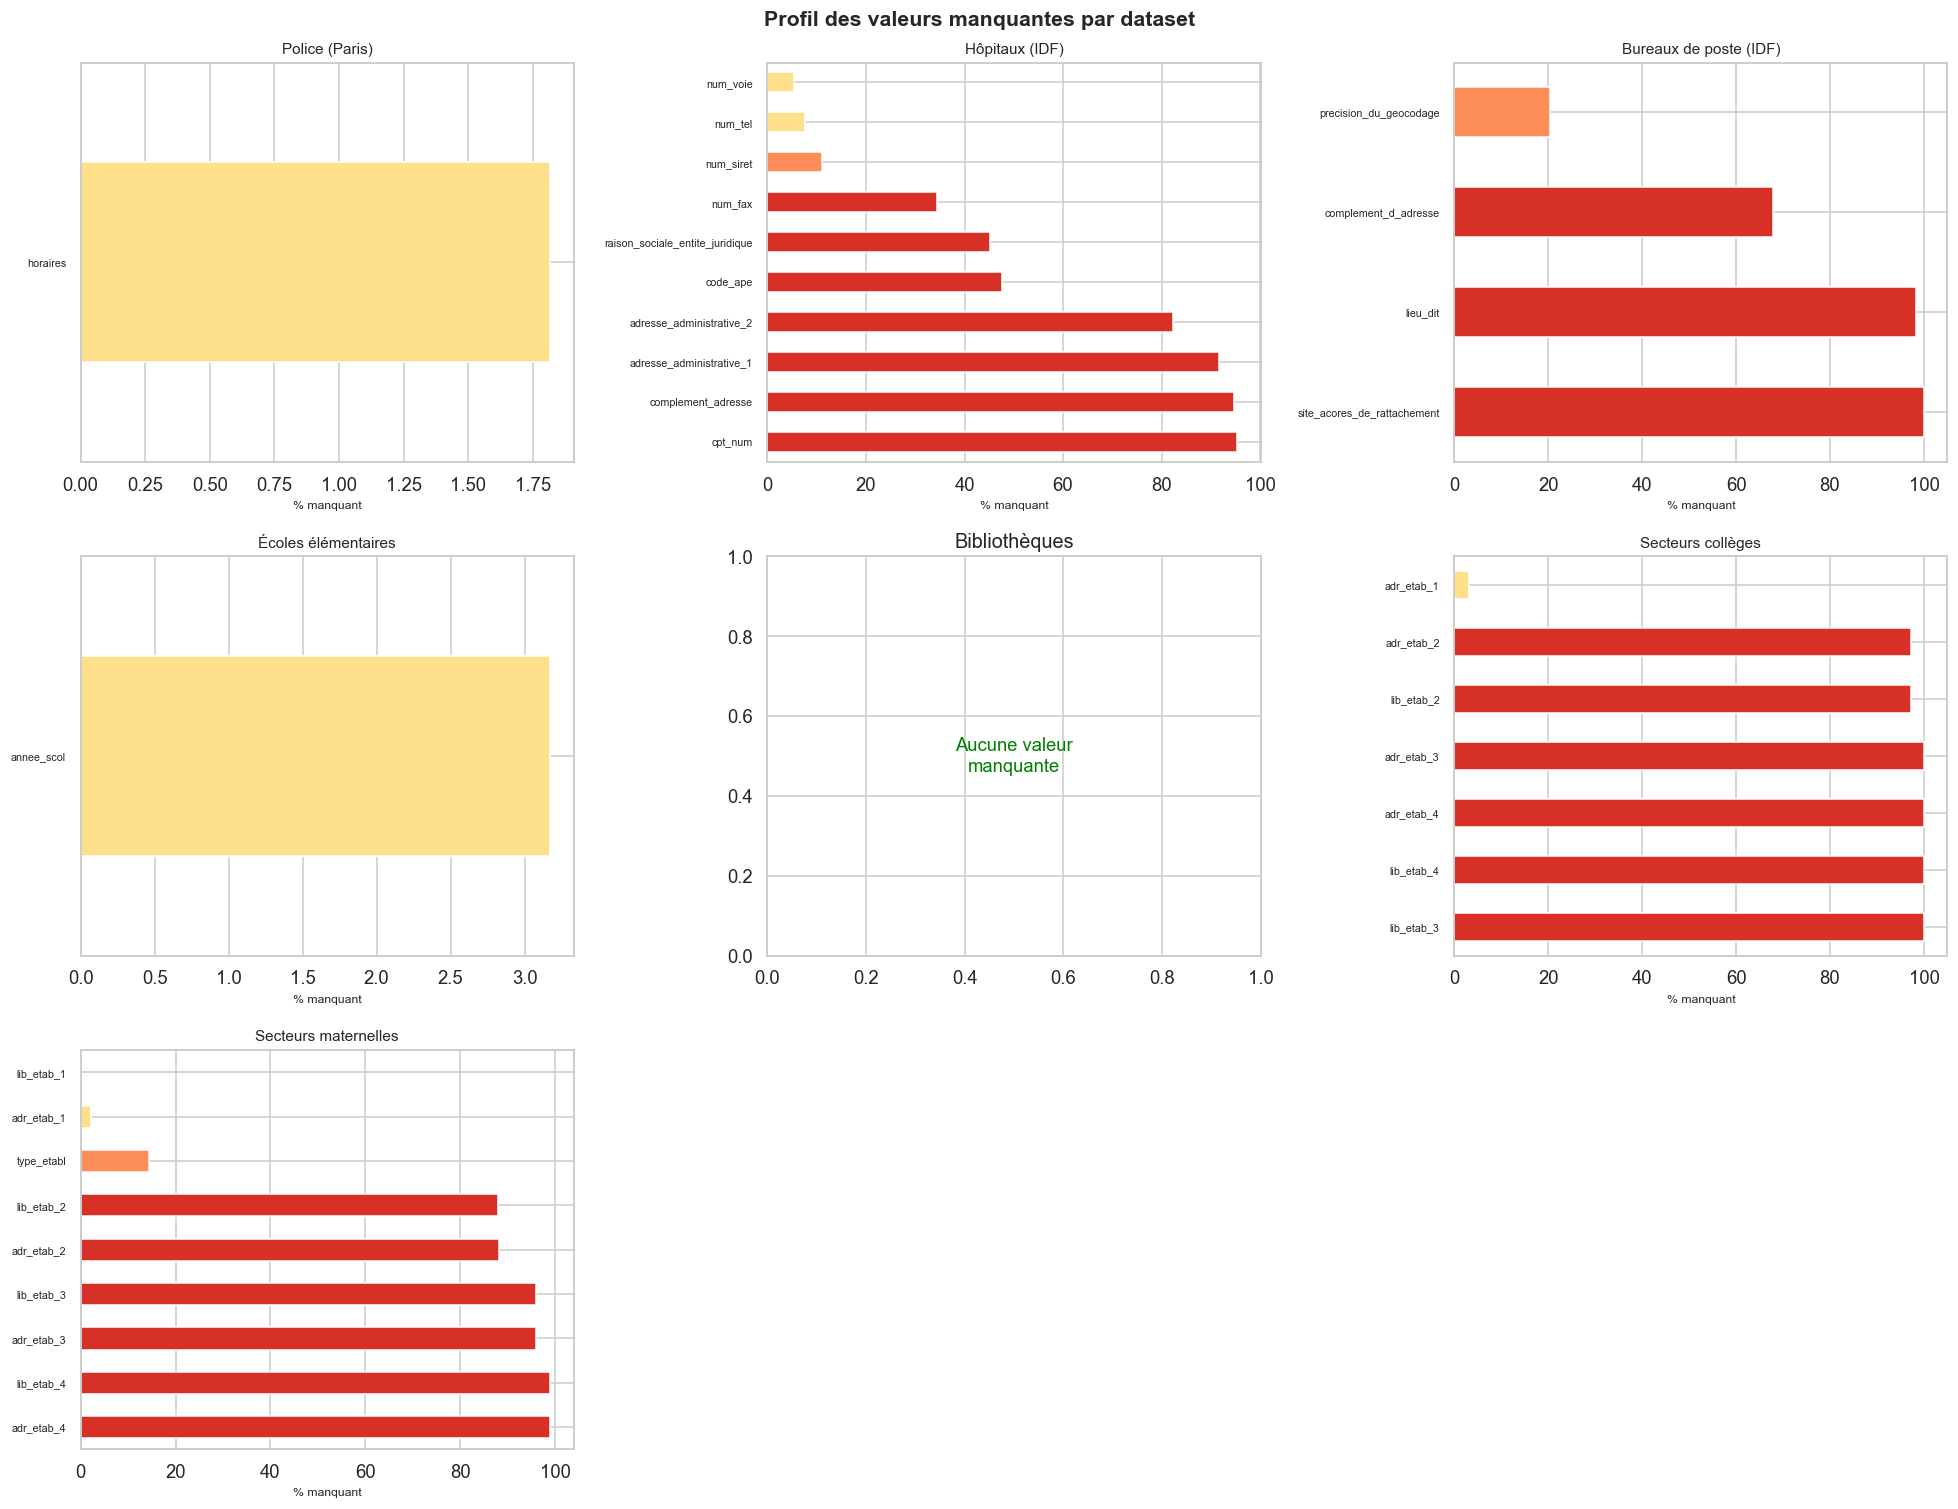

In [ ]:
# ── Distribution des valeurs manquantes par dataset ───────────────────────────
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes_flat = axes.flatten()

for i, (name, df) in enumerate(datasets.items()):
    ax = axes_flat[i]
    miss_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
    miss_pct = miss_pct[miss_pct > 0]
    if miss_pct.empty:
        ax.text(0.5, 0.5, 'Aucune valeur\nmanquante', transform=ax.transAxes,
                ha='center', va='center', fontsize=12, color='green')
        ax.set_title(name)
    else:
        colors_miss = ['#d73027' if v > 30 else '#fc8d59' if v > 10 else '#fee08b' for v in miss_pct.values]
        miss_pct.head(10).plot(kind='barh', ax=ax, color=colors_miss, edgecolor='white')
        ax.set_title(name, fontsize=10)
        ax.set_xlabel('% manquant', fontsize=8)
        ax.tick_params(axis='y', labelsize=7)

# Masquer les axes vides
for j in range(len(datasets), len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.suptitle('Profil des valeurs manquantes par dataset', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 13. Conclusion & Recommandations

### Résultats clés de l'EDA

| Observation | Détail |
|-------------|--------|
| **Périmètre géographique** | Datasets mixtes : Paris intra-muros (police, écoles, bibliothèques, secteurs scolaires) et Île-de-France (hôpitaux, bureaux de poste) |
| **Géocodage** | Couverture GPS généralement bonne sur les points d'accueil physiques (hôpitaux, poste, police) |
| **Granularité** | Arrondissement pour Paris ; département pour IDF — à homogénéiser par IRIS ou carreaux pour un score fin |
| **Services éducatifs** | Les secteurs scolaires maternelles (2 683) et élémentaires (2 237) constituent la masse principale des enregistrements |
| **Complétude** | Les données restent exploitables en l'état — aucun dataset ne présente de taux de manquants critique sur les variables clés |

### Prochaines étapes recommandées

1. **Homogénéiser le référentiel géographique** : ramener tous les datasets à l'IRIS ou au code commune INSEE (utiliser un référentiel géographique commun).
2. **Enrichir le score** avec la population de chaque zone (ratio établissements/habitants).
3. **Valider les pondérations** avec des experts en politiques publiques.
4. **Intégrer les bureaux de poste et bibliothèques** au score composite dès que le découpage arrondissement sera disponible.
5. **Mettre à jour les données** en vérifiant les millésimes de chaque source (certains datasets sont multi-annuels).